# YOLO26n 객체 탐지 학습 + 트래킹 (로컬 버전)

Colab 전용 코드(`google.colab`, `/content/...`)를 제거하고 로컬 PC(venv + GPU)에서 바로 돌아가도록 다시 만든 노트북입니다.

순서: **환경 확인 → 데이터셋 확인 → data.yaml 생성 → 학습 → 검증 → 예측 → 트래킹 → 모델 저장**

## 0. 패키지 설치 / 환경 확인
트래킹(ByteTrack/BoT-SORT)에는 `lap` 패키지가 필요합니다.

In [1]:
%pip install -q ultralytics lap

Note: you may need to restart the kernel to use updated packages.


In [2]:
import ultralytics, torch
ultralytics.checks()
print('CUDA 사용 가능:', torch.cuda.is_available())
DEVICE = 0 if torch.cuda.is_available() else 'cpu'

Ultralytics 8.4.170 🚀 Python-3.12.3 torch-2.14.1+cu130 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 5804MiB)
Setup complete ✅ (20 CPUs, 31.0 GB RAM, 59.7/232.6 GB disk)
CUDA 사용 가능: True


## 1. 경로 설정
`DATASET_DIR`만 본인 데이터셋 폴더로 바꾸면 됩니다. 폴더 구조는 아래와 같아야 합니다.
```
DATASET_DIR/
  train/images, train/labels
  valid/images, valid/labels
  test/images,  test/labels
```
`2_3_*.py` 스크립트로 만든 `my_data` 폴더를 쓰려면 `DATASET_DIR = Path('./my_data').resolve()` 로 바꾸세요.

In [3]:
from pathlib import Path

DATASET_DIR = Path.home() / 'Downloads' / 'yolo88'   # ← 데이터셋 경로
CLASS_NAMES = ['car', 'dummy']                                             # ← 라벨링한 클래스 순서 그대로

MODEL_WEIGHTS = 'yolov8s.pt'   # ← 학습할 모델 (yolov8n.pt, yolo11n.pt, yolo26n.pt, yolo26s.pt ...)
RUN_SUFFIX = '_tuned'          # ← 기존 결과를 덮어쓰지 않도록 붙이는 꼬리표 ('' 이면 기존 폴더에 덮어씀)
MODEL_TAG = Path(MODEL_WEIGHTS).stem.removeprefix('yolo') + RUN_SUFFIX   # yolov8s + _tuned → v8s_tuned

WORK_DIR = Path.cwd()                 # 결과물 저장 위치 (이 노트북이 있는 폴더)
RUNS_DIR = WORK_DIR / 'runs'
RUN_NAME = f'car_dummy_{MODEL_TAG}'   # 모델별로 결과 폴더 분리 (runs/car_dummy_11n ...)

assert DATASET_DIR.exists(), f'데이터셋 폴더가 없습니다: {DATASET_DIR}'
print('DATASET_DIR =', DATASET_DIR)
print('MODEL     =', MODEL_WEIGHTS, '→', RUNS_DIR / RUN_NAME)

DATASET_DIR = /home/hv-06/Downloads/yolo88
MODEL     = yolov8s.pt → /home/hv-06/rokey_ws/runs/car_dummy_v8s


## 2. 데이터셋 확인
이미지/라벨 개수가 맞는지, 라벨의 클래스 번호가 `CLASS_NAMES` 범위 안에 있는지 검사합니다. (학습 에러의 대부분이 여기서 걸립니다)

In [4]:
from collections import Counter

IMG_EXT = {'.jpg', '.jpeg', '.png', '.bmp'}
cls_counter = Counter()
ok = True

for split in ['train', 'valid', 'test']:
    img_dir, lbl_dir = DATASET_DIR / split / 'images', DATASET_DIR / split / 'labels'
    imgs = [p for p in img_dir.glob('*') if p.suffix.lower() in IMG_EXT]
    lbls = list(lbl_dir.glob('*.txt'))
    no_label = [p.name for p in imgs if not (lbl_dir / (p.stem + '.txt')).exists()]
    print(f'{split:5s}: 이미지 {len(imgs):4d}장 / 라벨 {len(lbls):4d}개 / 라벨 없는 이미지 {len(no_label)}개')
    if split in ('train', 'valid') and len(imgs) == 0:
        ok = False
        print(f'  !! {split} 이미지가 없습니다')
    for lf in lbls:
        for line in lf.read_text().splitlines():
            if not line.strip():
                continue
            c = int(line.split()[0])
            cls_counter[c] += 1
            if c >= len(CLASS_NAMES):
                ok = False
                print(f'  !! {lf.name}: 클래스 번호 {c} 가 CLASS_NAMES 범위를 벗어남')

print('클래스별 박스 수:', {CLASS_NAMES[c] if c < len(CLASS_NAMES) else c: n for c, n in sorted(cls_counter.items())})
print('데이터셋 OK' if ok else '데이터셋에 문제가 있습니다. 위 메시지를 확인하세요.')

train: 이미지   87장 / 라벨   87개 / 라벨 없는 이미지 0개
valid: 이미지   25장 / 라벨   25개 / 라벨 없는 이미지 0개
test : 이미지   12장 / 라벨   12개 / 라벨 없는 이미지 0개
클래스별 박스 수: {'car': 124, 'dummy': 124}
데이터셋 OK


/home/hv-06/venvs/rokey_venv/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


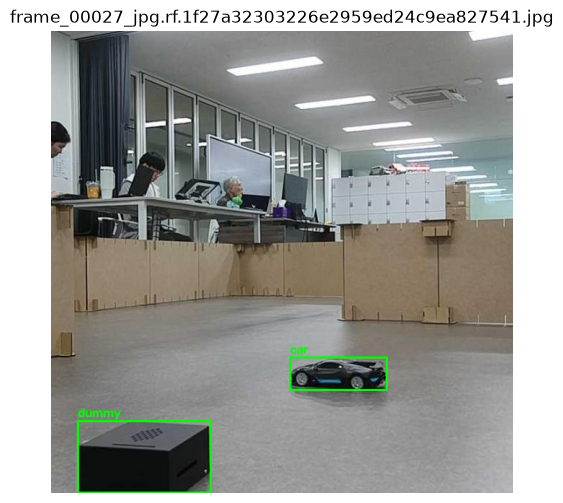

In [5]:
# 라벨 박스가 제대로 그려지는지 랜덤 이미지로 확인
import random, cv2
import matplotlib.pyplot as plt

img_path = random.choice(list((DATASET_DIR / 'train' / 'images').glob('*')))
img = cv2.imread(str(img_path))
h, w = img.shape[:2]
lbl_path = DATASET_DIR / 'train' / 'labels' / (img_path.stem + '.txt')
for line in lbl_path.read_text().splitlines():
    if not line.strip():
        continue
    c, xc, yc, bw, bh = line.split()
    xc, yc, bw, bh = float(xc) * w, float(yc) * h, float(bw) * w, float(bh) * h
    p1, p2 = (int(xc - bw / 2), int(yc - bh / 2)), (int(xc + bw / 2), int(yc + bh / 2))
    cv2.rectangle(img, p1, p2, (0, 255, 0), 2)
    cv2.putText(img, CLASS_NAMES[int(c)], (p1[0], p1[1] - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

plt.figure(figsize=(8, 6)); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title(img_path.name); plt.axis('off'); plt.show()

## 3. data.yaml 생성
Roboflow가 준 `data.yaml`의 `../train/images` 같은 상대경로는 에러의 원인이 되므로, **절대경로**로 새 yaml을 만듭니다.

In [6]:
import yaml

data_cfg = {
    'path': str(DATASET_DIR),
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': len(CLASS_NAMES),
    'names': CLASS_NAMES,
}
DATA_YAML = WORK_DIR / 'custom_data.yaml'
with open(DATA_YAML, 'w') as f:
    yaml.safe_dump(data_cfg, f, allow_unicode=True, sort_keys=False)

print(DATA_YAML.read_text())

path: /home/hv-06/Downloads/yolo88
train: train/images
val: valid/images
test: test/images
nc: 2
names:
- car
- dummy



## 4. 학습
- 1번 셀의 `MODEL_WEIGHTS` (COCO 사전학습)에서 시작합니다. 처음 실행 시 자동 다운로드됩니다.
- 실행 중에는 기본 진행표와 함께 매 에폭 종료 시 loss, Precision, Recall, mAP50-95 요약이 출력됩니다.
- 하이퍼파라미터는 `TRAIN_ARGS`에 넣습니다. 여기 넣은 값과 실제 학습 시간이 `train_info.yaml`로 저장되어 통계/비교 리포트에 표시됩니다.
- `results.csv`와 `results.png`는 매 에폭 갱신되며, 중간 가중치는 10 에폭마다 저장됩니다.
- 노트북 GPU 메모리(6GB)를 고려해 `batch=16`. 메모리 부족(`CUDA out of memory`) 에러가 나면 8로 줄이세요.
- `workers=2` : 노트북에서 dataloader 관련 에러/멈춤 방지

In [7]:
import time
from ultralytics import YOLO

# ← 학습 하이퍼파라미터: 여기 넣은 값이 train_info.yaml에 저장되어 통계/비교 리포트에 표시됩니다.
# 추천 조합 (소규모 데이터 87장 + yolov8s 초반 발산 대응)
TRAIN_ARGS = dict(
    epochs=150,
    patience=50,          # 초반 발산 후 회복할 시간 확보 (20이면 회복 도중 조기 종료됨)
    imgsz=640,
    batch=16,
    workers=2,
    cache='ram',          # 87장이라 RAM에 올려두면 빨라짐
    # Optimizer / LR: optimizer='auto'(AdamW, lr≈0.0017)에서 발산 → SGD + 낮은 lr
    optimizer='SGD',      # 또는 optimizer='AdamW', lr0=0.0005
    lr0=0.005,
    cos_lr=True,          # cosine 스케줄로 부드럽게 감소
    warmup_epochs=5,      # warmup 연장 → 초반 큰 gradient 완화
    warmup_bias_lr=0.05,  # 기본 0.1 → 낮춤
    freeze=10,            # backbone(0~9 레이어) 고정 → 사전학습 특징 보존, 발산/과적합 억제
    # Augmentation
    degrees=5,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,
    close_mosaic=10,
)

# 검증까지 끝난 각 에폭의 핵심 지표를 한 줄로 표시합니다.
def print_epoch_summary(trainer):
    metrics = trainer.metrics
    epoch = trainer.epoch + 1
    print(
        f'\n[에폭 {epoch:>3}/{trainer.epochs}] ' 
        # loss 항목은 모델마다 다름 (v8: box/cls/dfl, YOLO26: box/cls/l1)
        + ' / '.join(f"{n}={metrics.get(f'train/{n}', 0):.4f}" for n in trainer.loss_names) + ' | '
        f"P={metrics.get('metrics/precision(B)', 0):.3f}, "
        f"R={metrics.get('metrics/recall(B)', 0):.3f}, "
        f"mAP50={metrics.get('metrics/mAP50(B)', 0):.3f}, "
        f"mAP50-95={metrics.get('metrics/mAP50-95(B)', 0):.3f}"
    )

model = YOLO(MODEL_WEIGHTS)
model.add_callback('on_fit_epoch_end', print_epoch_summary)

print(f'학습 시작: {MODEL_WEIGHTS} → {RUNS_DIR / RUN_NAME}')
train_start = time.time()
results = model.train(
    **TRAIN_ARGS,
    data=str(DATA_YAML),
    device=DEVICE,
    project=str(RUNS_DIR),
    name=RUN_NAME,
    exist_ok=True,      # 다시 돌려도 train2, train3... 로 늘어나지 않음
    verbose=True,       # 배치/에폭 진행률을 노트북 출력에 표시
    plots=True,         # results.png, confusion_matrix.png 등을 생성
    save_period=10,     # 10 에폭마다 중간 체크포인트 저장
)
train_wall_s = time.time() - train_start   # 준비·최종 검증까지 포함한 실제 소요 시간


학습 시작: yolov8s.pt → /home/hv-06/rokey_ws/runs/car_dummy_v8s
New https://pypi.org/project/ultralytics/8.4.171 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.170 🚀 Python-3.12.3 torch-2.14.1+cu130 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 5804MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/hv-06/rokey_ws/custom_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0

In [8]:
import yaml
from yolo_report_utils import TRAIN_INFO, load_run, run_info_lines

# 실제로 저장된 폴더를 사용 (경로 하드코딩 X)
TRAIN_DIR = Path(model.trainer.save_dir)
BEST_PT = TRAIN_DIR / 'weights' / 'best.pt'
print('학습 결과 폴더:', TRAIN_DIR)
print('best.pt      :', BEST_PT, BEST_PT.exists())

# 사용자 하이퍼파라미터 + 실제 소요 시간 저장 → yolo_stats.py / yolo_compare.py가 읽음
with open(TRAIN_DIR / TRAIN_INFO, 'w') as f:
    yaml.safe_dump({'model': MODEL_WEIGHTS, 'user_hparams': TRAIN_ARGS, 'wall_time_s': round(train_wall_s, 1)},
                   f, allow_unicode=True, sort_keys=False)

# Epochs(설정/실제/best), 조기 종료 여부, Total Training Time, 하이퍼파라미터
print('\n'.join(run_info_lines(load_run(TRAIN_DIR, WORK_DIR))))


학습 결과 폴더: /home/hv-06/rokey_ws/runs/car_dummy_v8s
best.pt      : /home/hv-06/rokey_ws/runs/car_dummy_v8s/weights/best.pt True
- 모델: yolov8s.pt
- Epochs: 설정 100 / 실제 21 / best 1 (patience 20)
- 종료 상태: 조기 종료 (epoch 21에서 종료, 20 epoch 동안 개선 없음)
- Total Training Time: 0분 32초 (results.csv 기준)
- 실제 소요 시간(준비·최종 검증 포함): 0분 37초
- Training Hyper Parameters (학습 노트북 TRAIN_ARGS (train_info.yaml)):
    epochs: 100
    patience: 20
    imgsz: 640
    batch: 16
    workers: 2


## 5. 학습 결과 보기

results.png


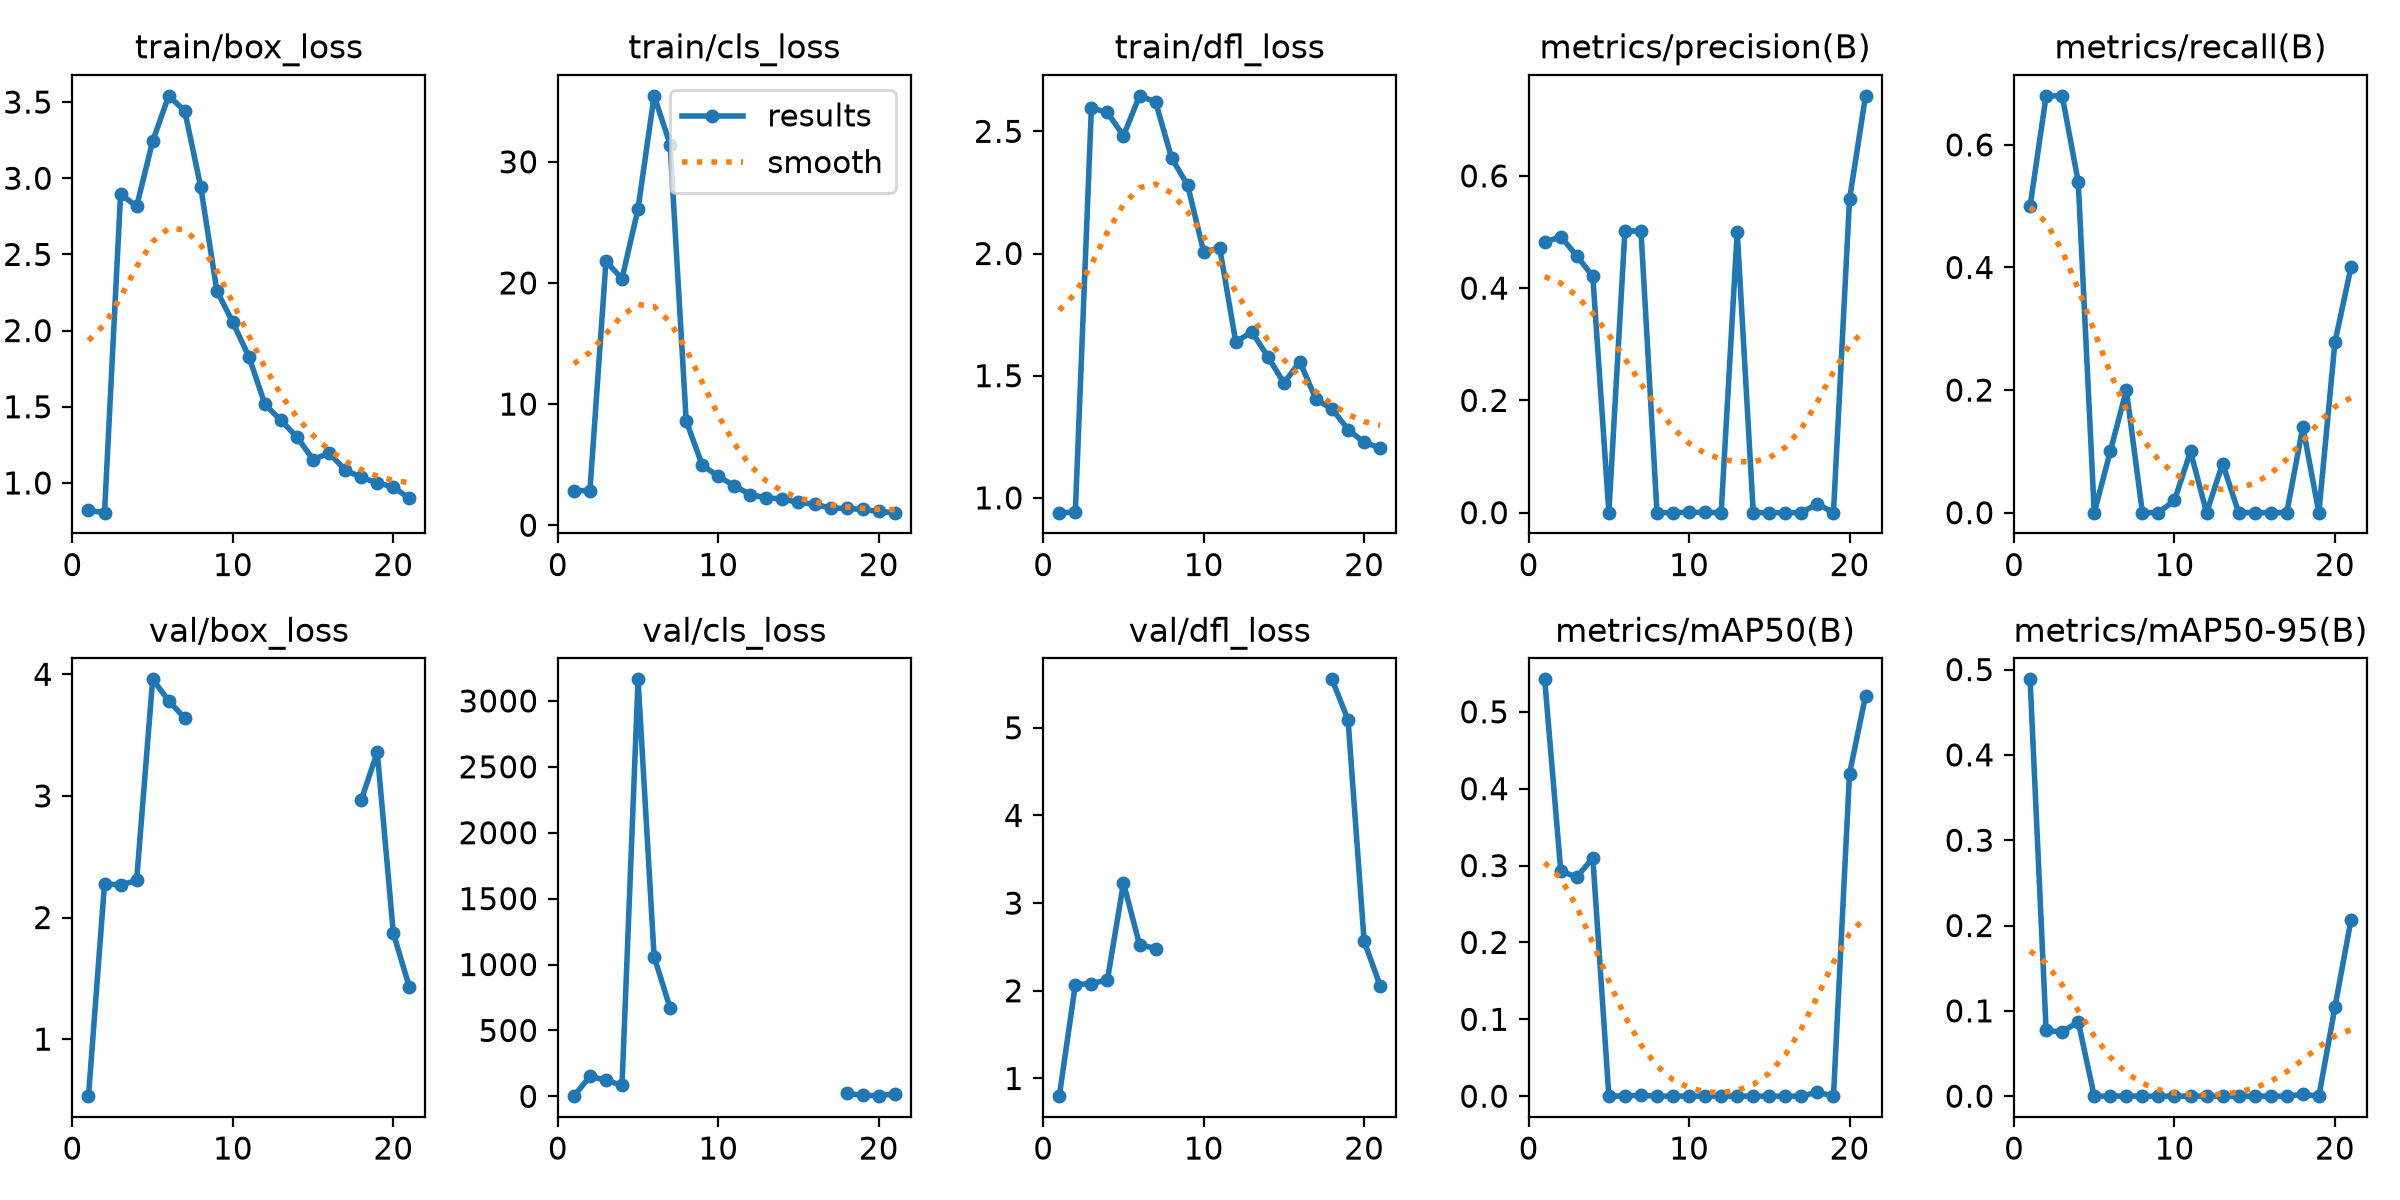

confusion_matrix.png


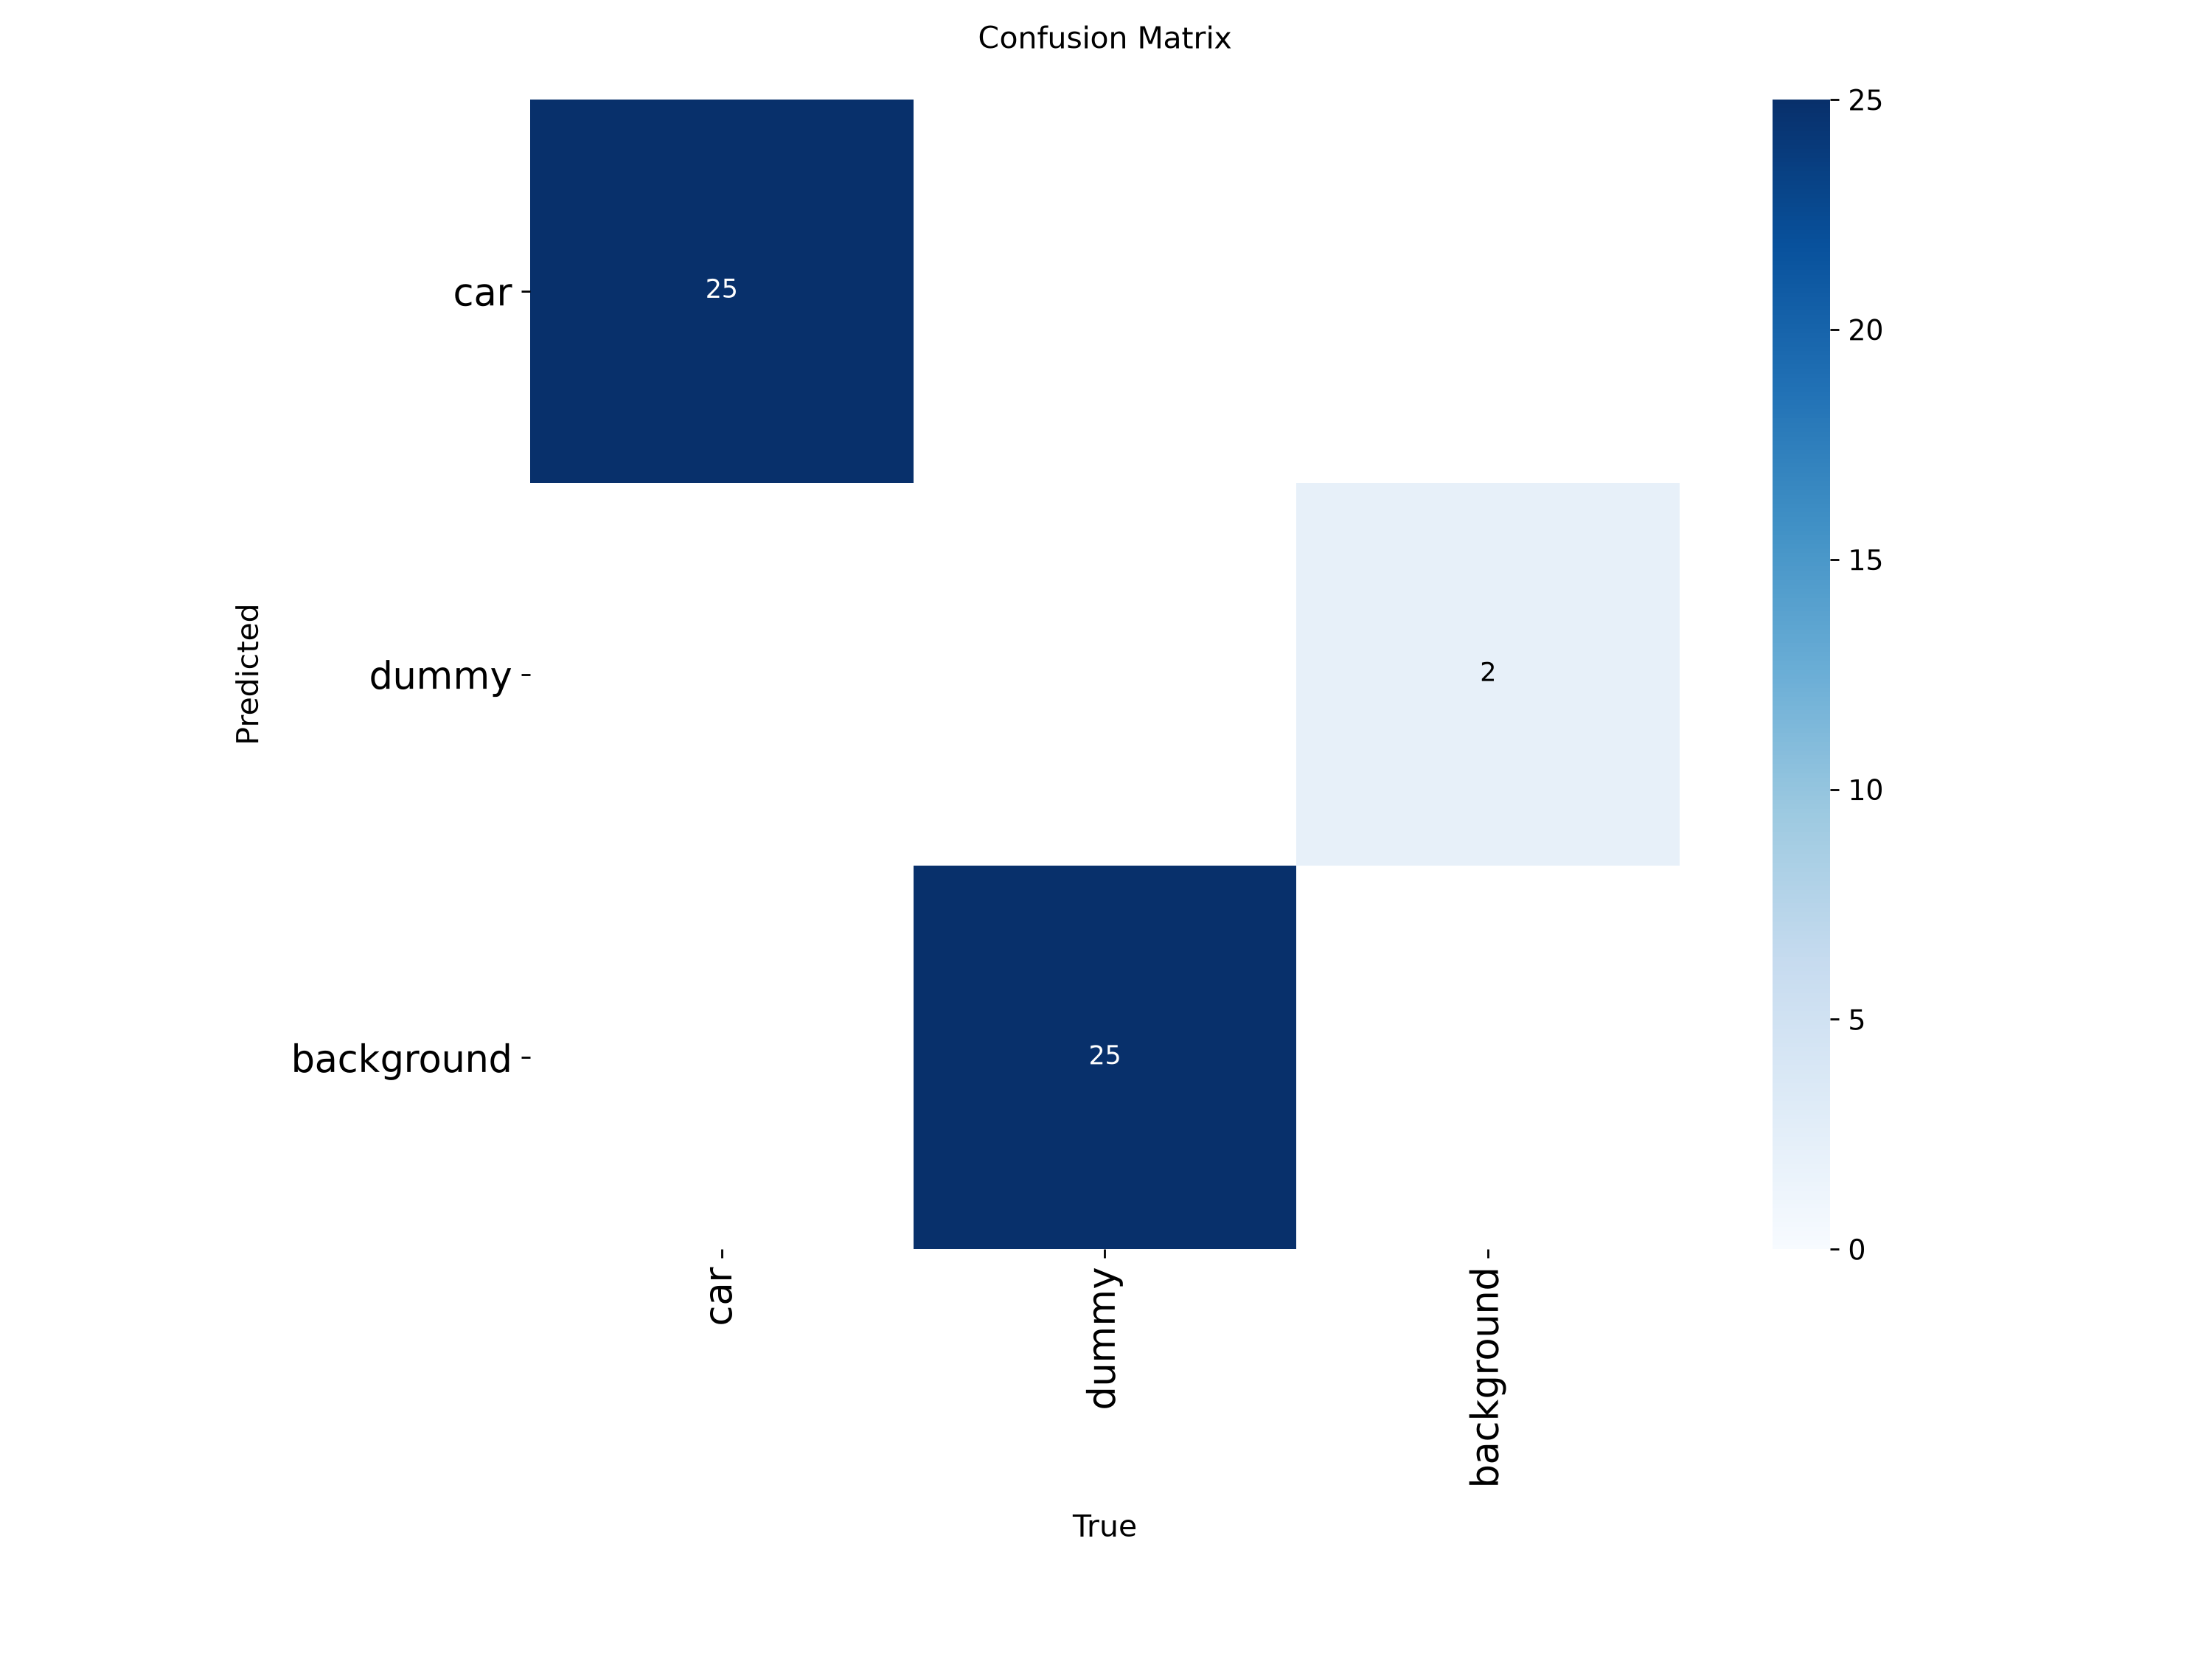

train_batch0.jpg


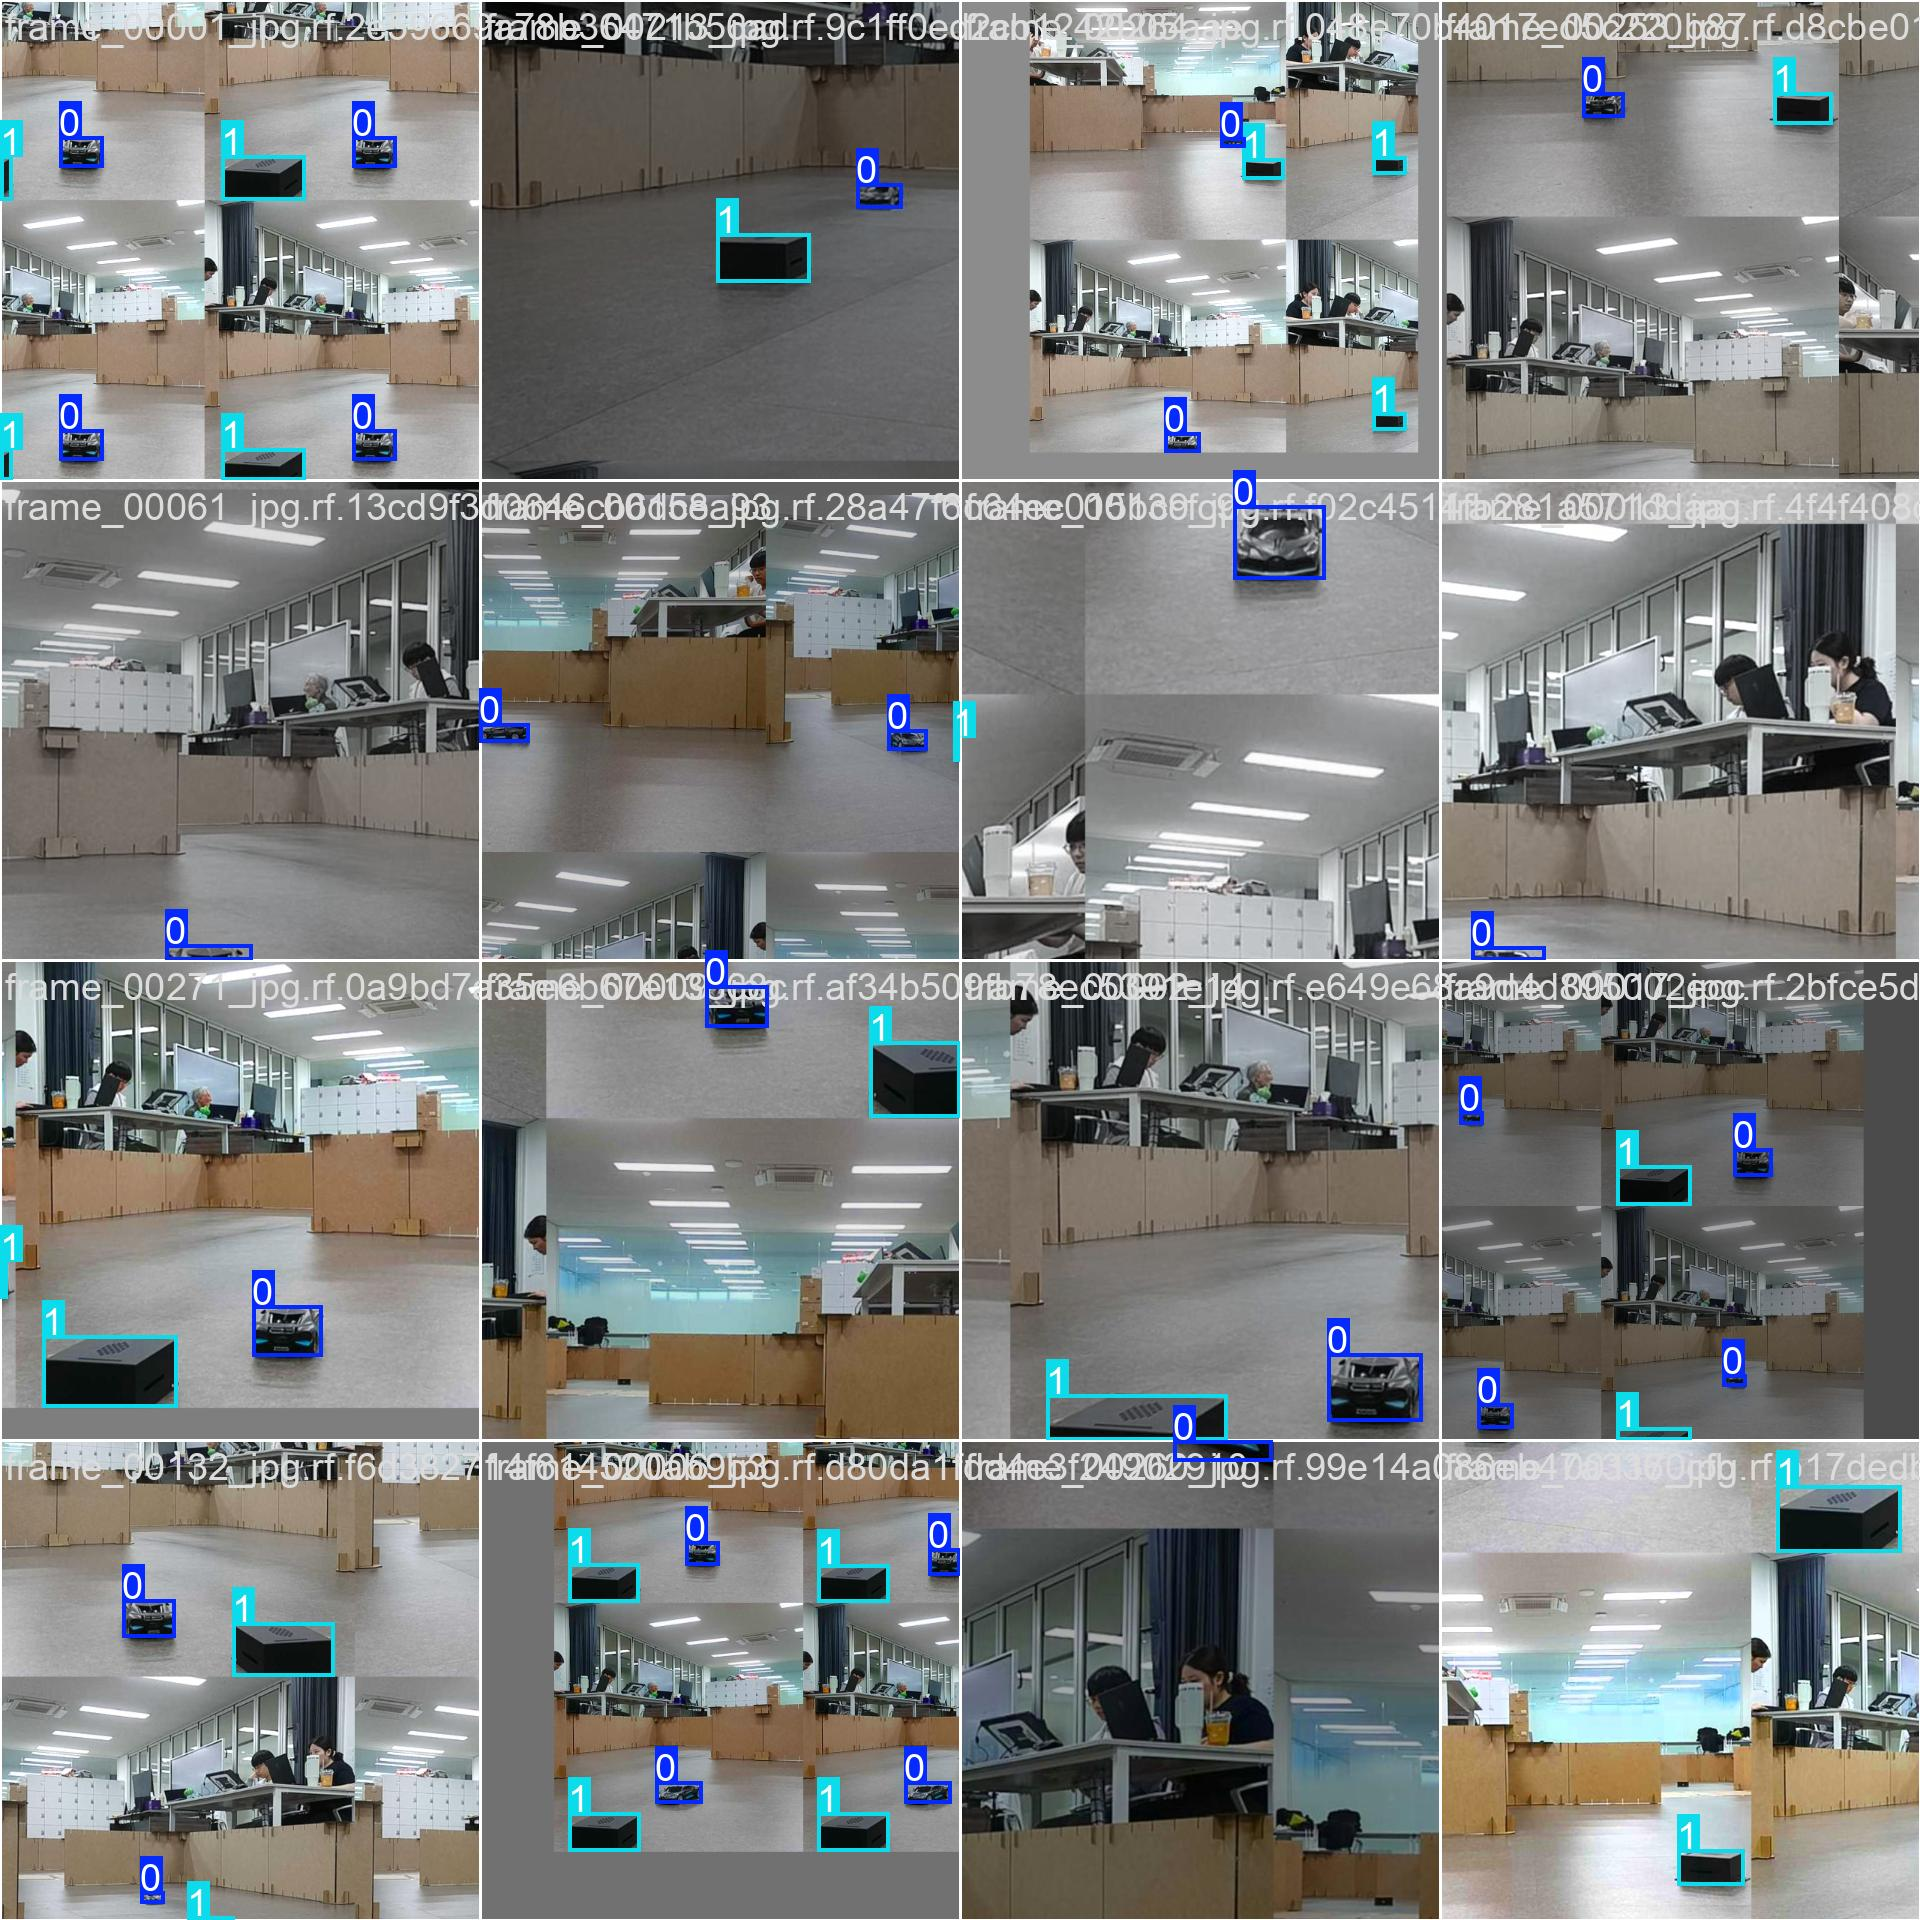

val_batch0_labels.jpg


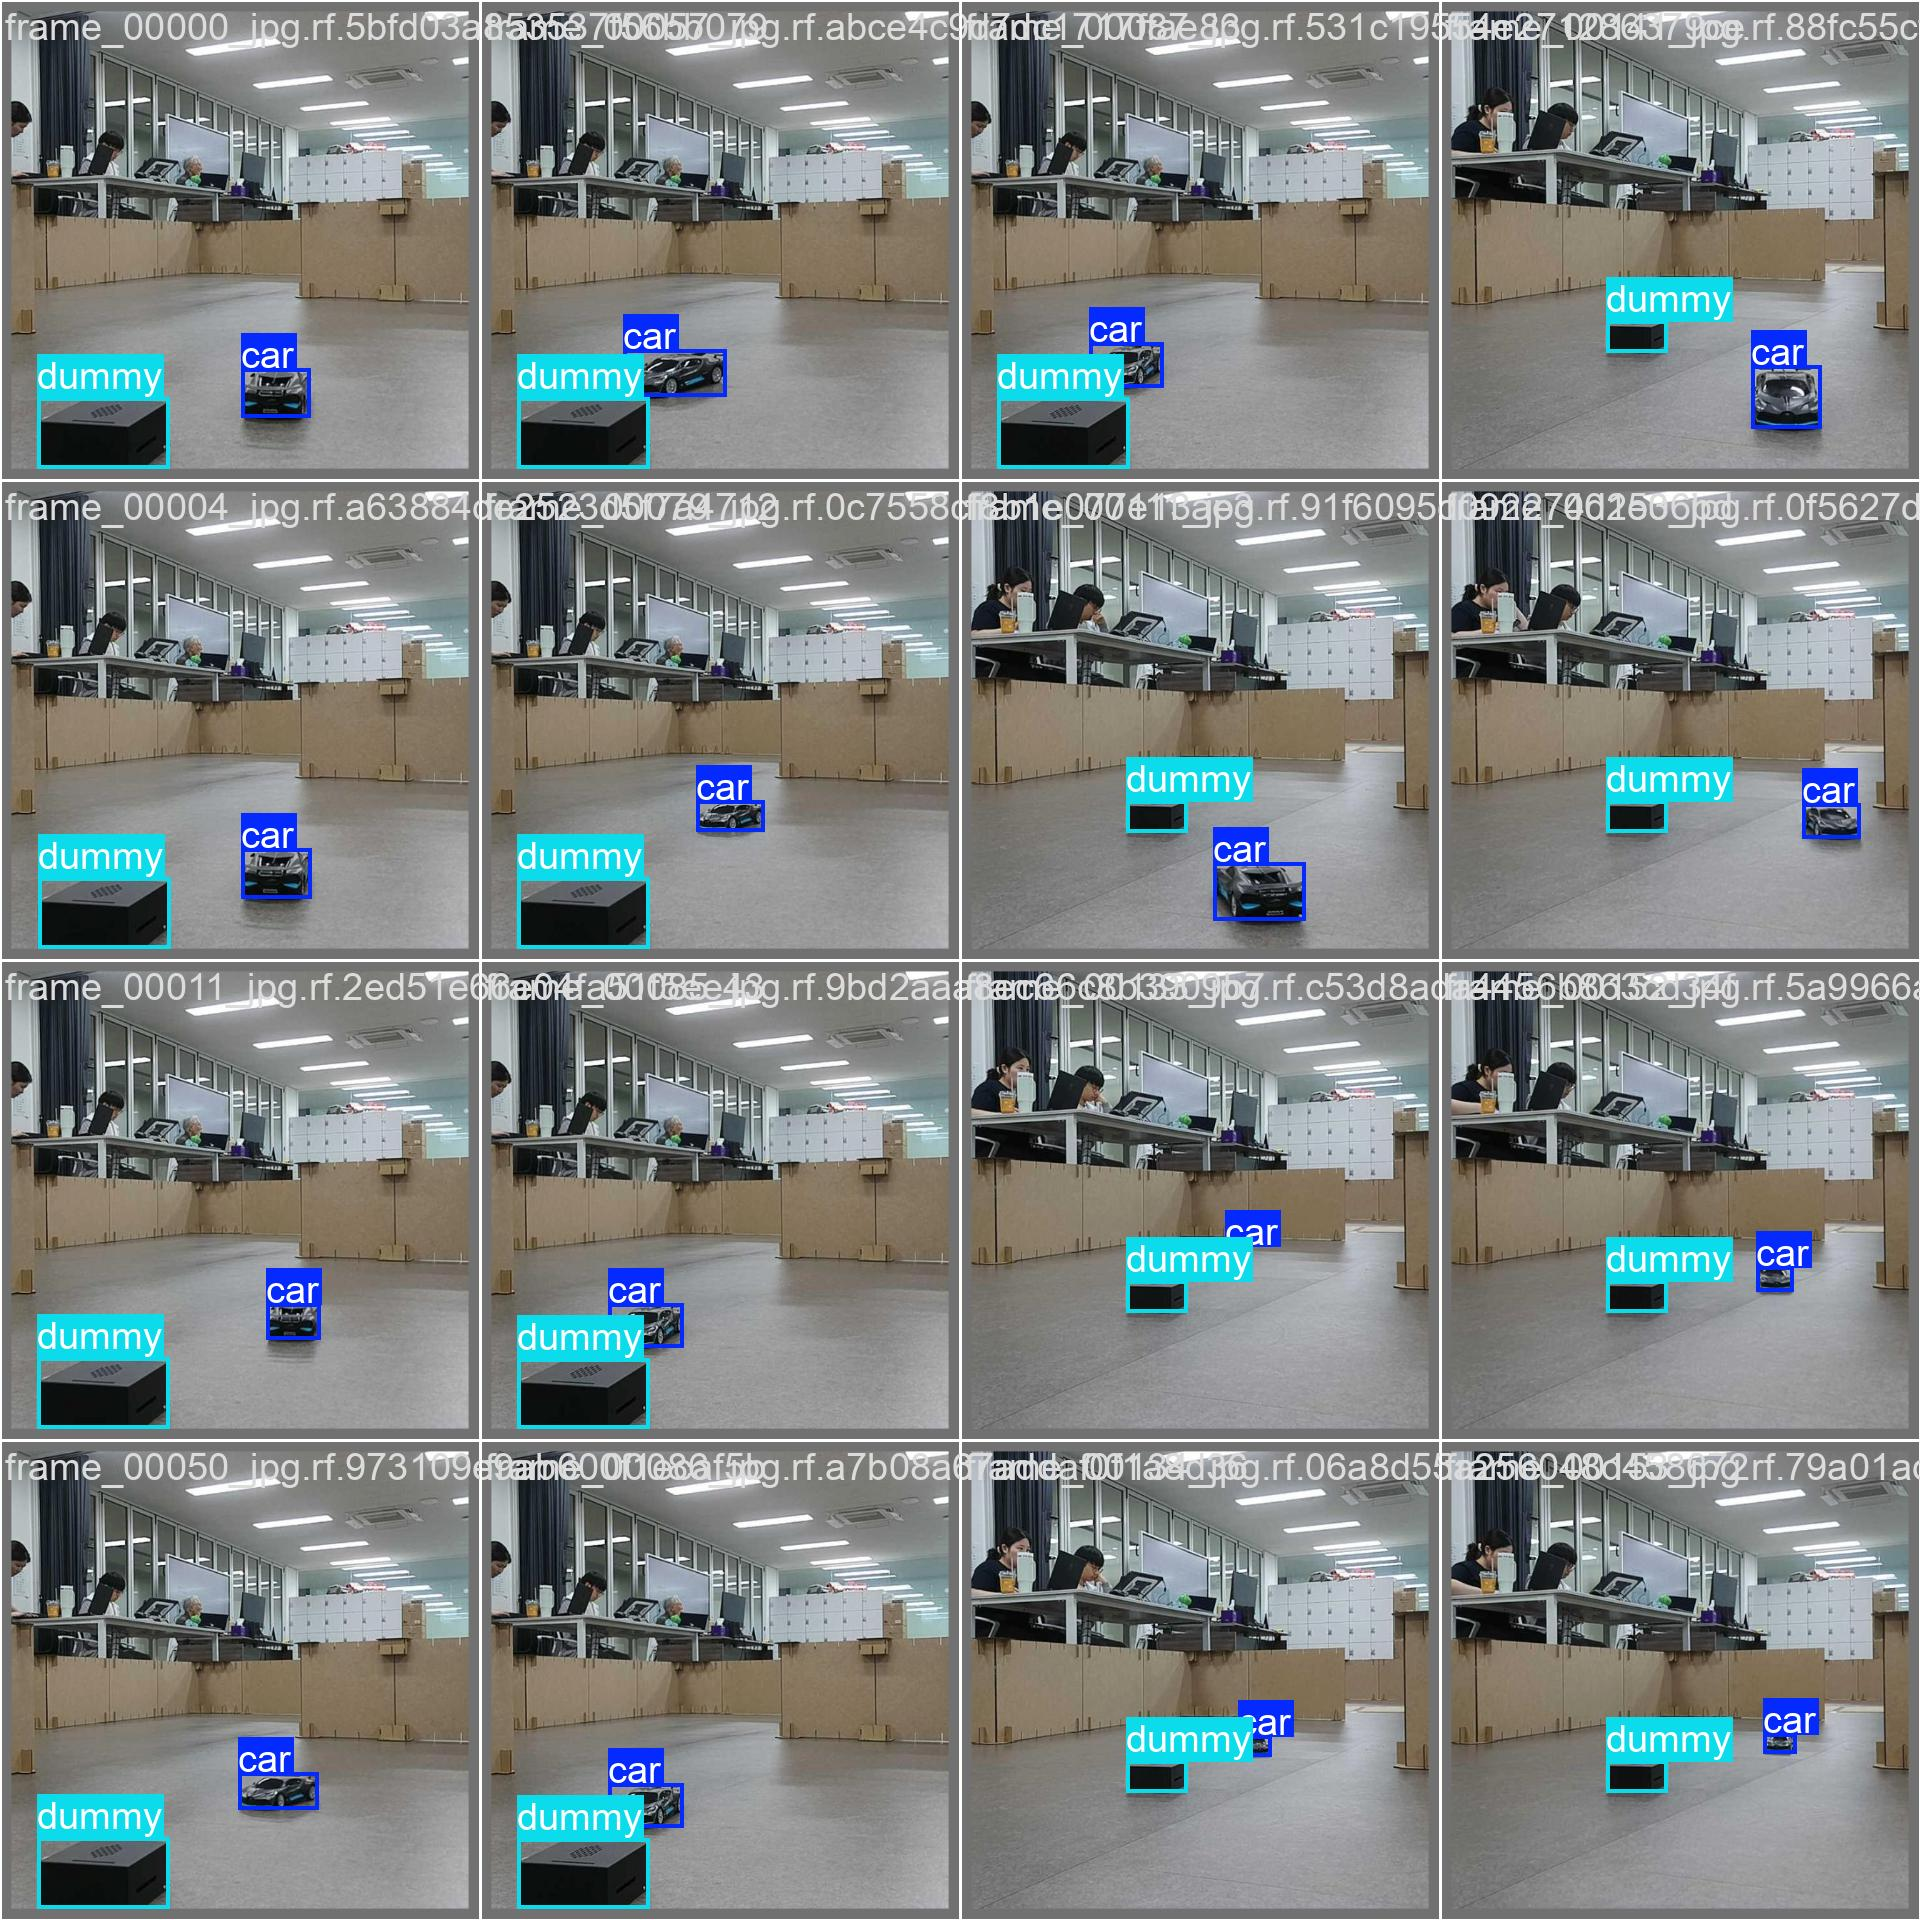

val_batch0_pred.jpg


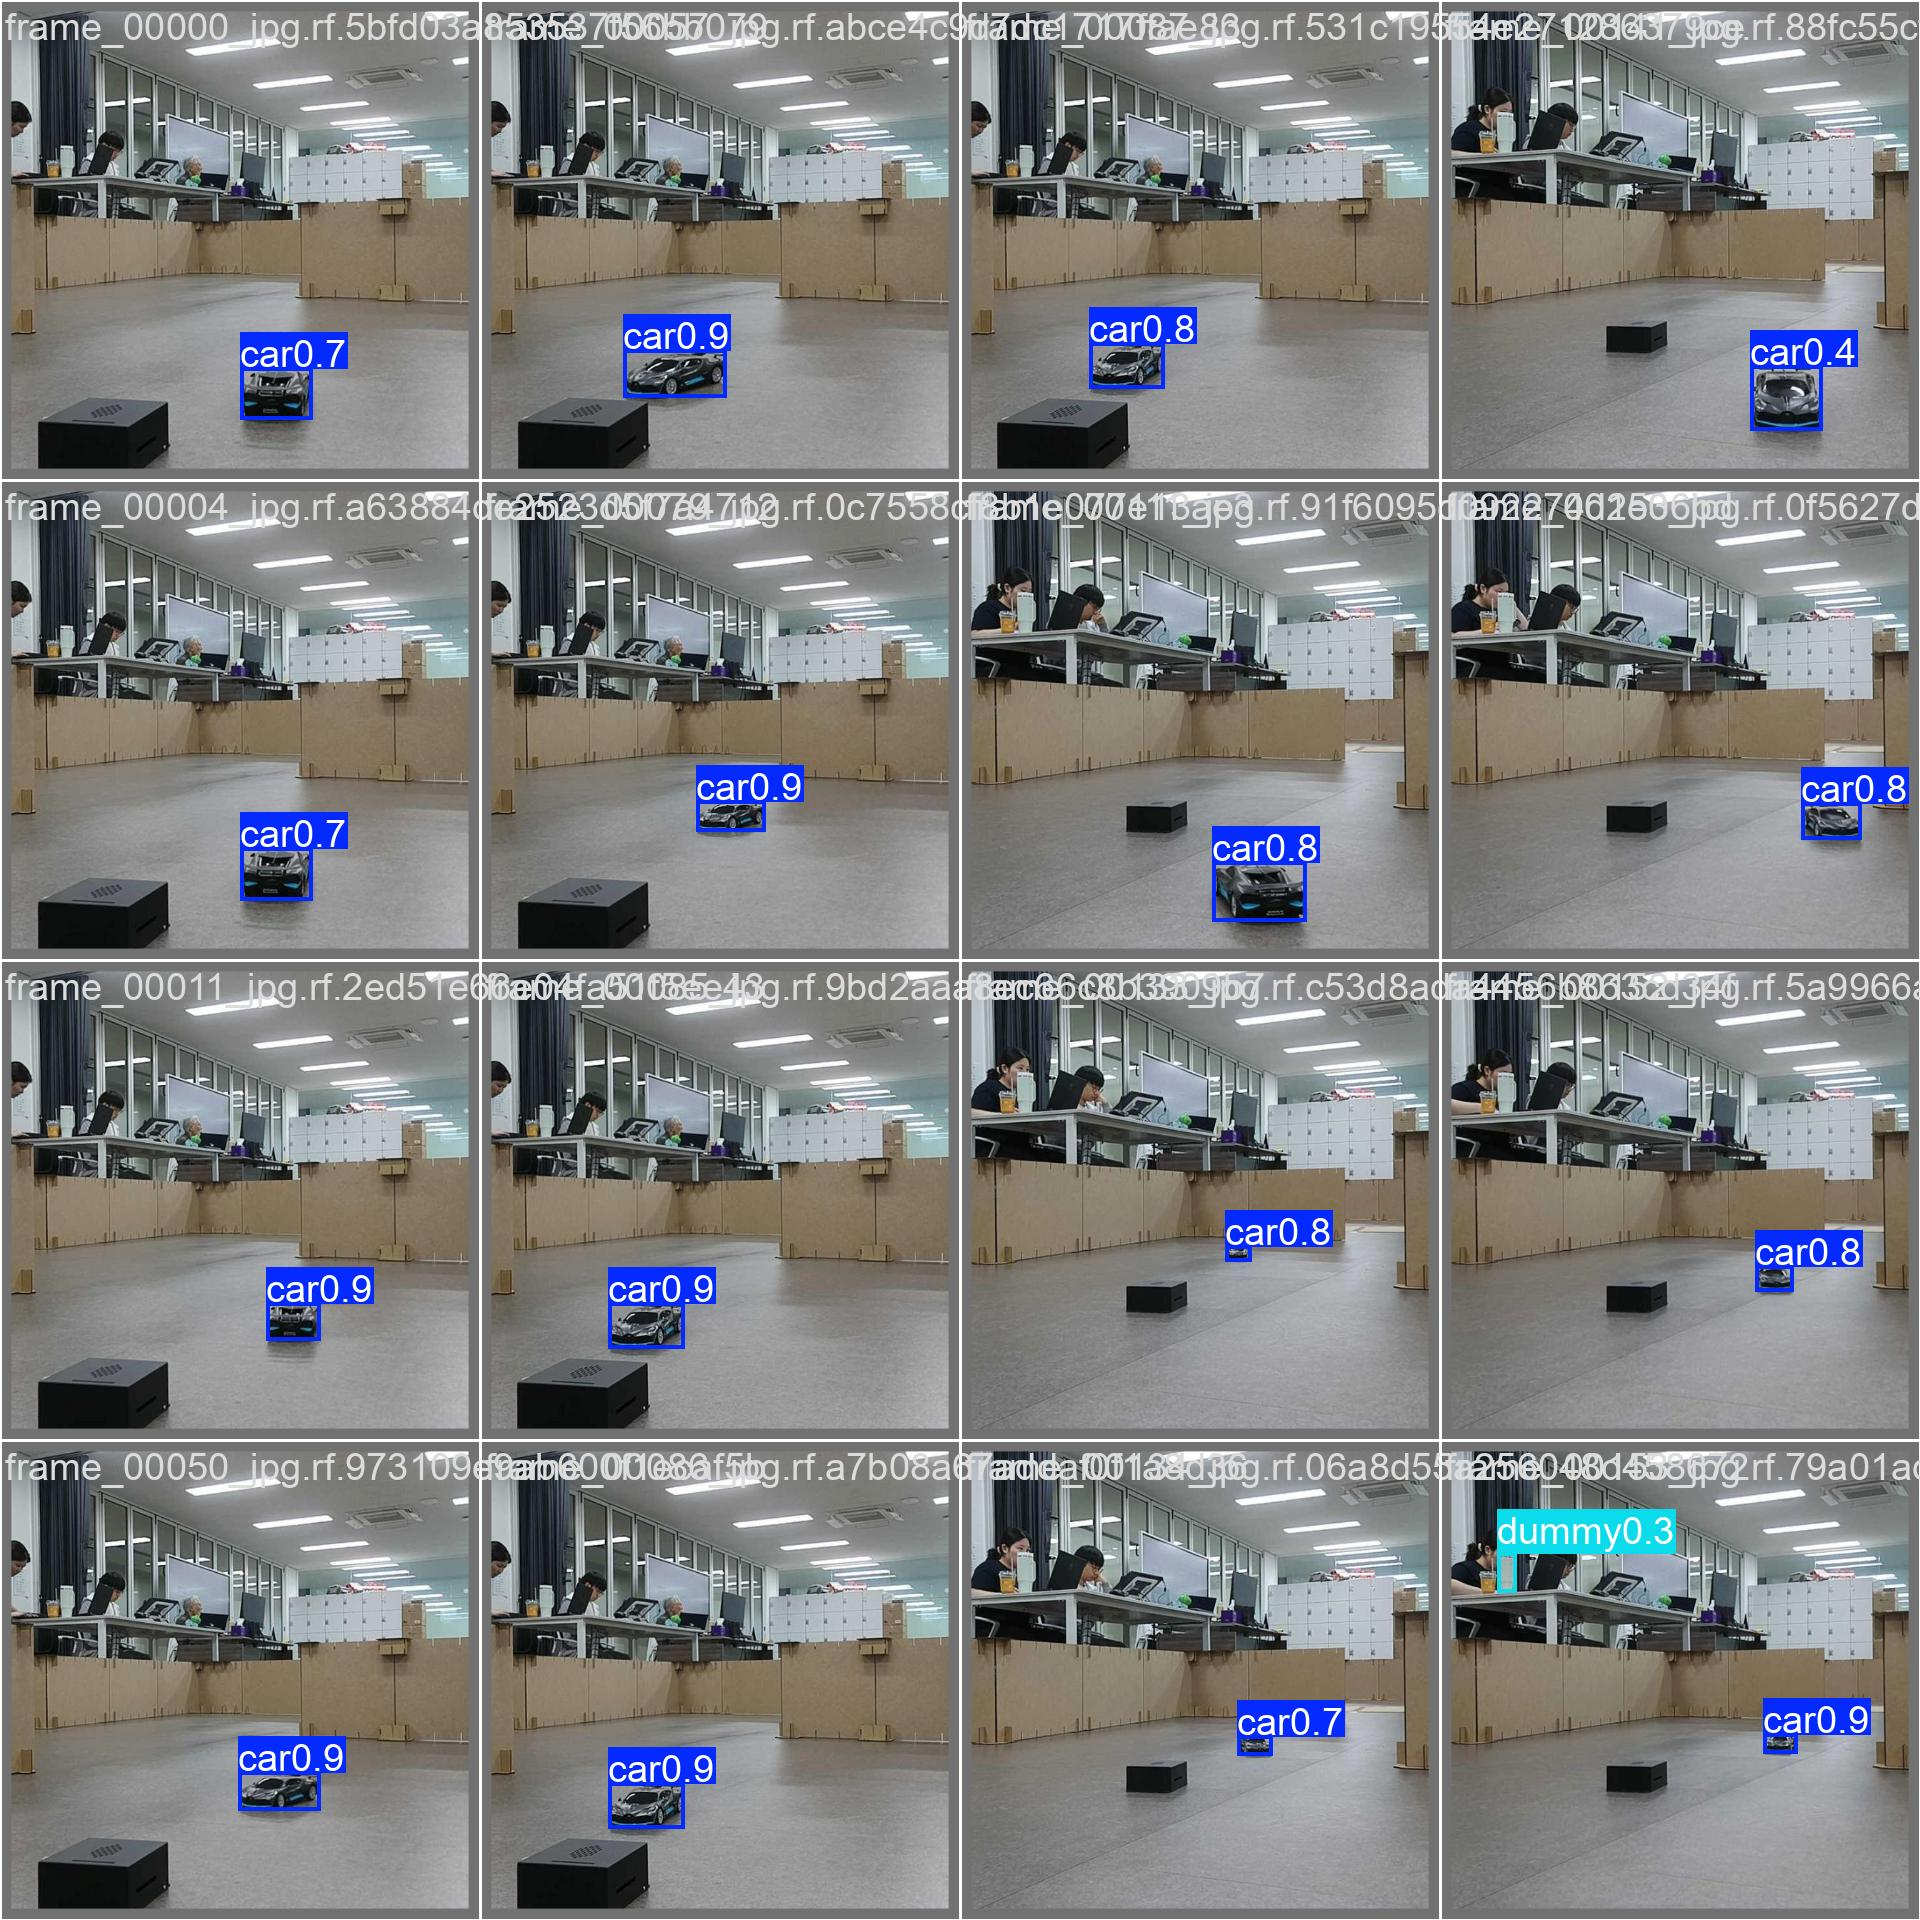

In [9]:
from IPython.display import Image, display

for name in ['results.png', 'confusion_matrix.png', 'train_batch0.jpg', 'val_batch0_labels.jpg', 'val_batch0_pred.jpg']:
    p = TRAIN_DIR / name
    if p.exists():
        print(name); display(Image(filename=str(p), width=900))

## 6. 검증 (test 셋)

In [10]:
best_model = YOLO(str(BEST_PT))
print(best_model.names)

metrics = best_model.val(data=str(DATA_YAML), split='test', device=DEVICE,
                         project=str(RUNS_DIR), name=RUN_NAME + '_test', exist_ok=True)
print(f'mAP50   : {metrics.box.map50:.3f}')
print(f'mAP50-95: {metrics.box.map:.3f}')

{0: 'car', 1: 'dummy'}
Ultralytics 8.4.170 🚀 Python-3.12.3 torch-2.14.1+cu130 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 5804MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3776.6±901.2 MB/s, size: 45.4 KB)
val: Scanning /home/hv-06/Downloads/yolo88/test/labels.cache... 12 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 12/12 7.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 7.0it/s 0.1s
                   all         12         24      0.521      0.542      0.567        0.5
                   car         12         12      0.967          1      0.995      0.877
                 dummy         12         12     0.0751     0.0833      0.139      0.122
Speed: 0.2ms preprocess, 6.5ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /home/hv-06/rokey_ws/runs/car_dummy_v8s_test
mAP50   : 0.567
mAP50-95: 0.

## 7. 이미지 예측


image 1/12 /home/hv-06/Downloads/yolo88/test/images/frame_00090_jpg.rf.32679ceea4a7e67791f684d286eb61b7.jpg: 640x640 1 car, 6.0ms
image 2/12 /home/hv-06/Downloads/yolo88/test/images/frame_00116_jpg.rf.2ed1c253fc682fc85a68d49291f1aa5c.jpg: 640x640 1 car, 6.3ms
image 3/12 /home/hv-06/Downloads/yolo88/test/images/frame_00135_jpg.rf.d54d97d4185b1f75c5949d7f73511d06.jpg: 640x640 1 car, 6.6ms
image 4/12 /home/hv-06/Downloads/yolo88/test/images/frame_00136_jpg.rf.aaeb36275c3b61088891530df2c273a9.jpg: 640x640 1 car, 6.5ms
image 5/12 /home/hv-06/Downloads/yolo88/test/images/frame_00140_jpg.rf.61770448578ca6d383f48d1cc64173c0.jpg: 640x640 1 car, 6.4ms
image 6/12 /home/hv-06/Downloads/yolo88/test/images/frame_00142_jpg.rf.ed404c98c931b03775c37ed5b48d2ee7.jpg: 640x640 1 car, 6.3ms
image 7/12 /home/hv-06/Downloads/yolo88/test/images/frame_00156_jpg.rf.9bb54926cb5444a490d9021a46bd1a51.jpg: 640x640 1 car, 6.4ms
image 8/12 /home/hv-06/Downloads/yolo88/test/images/frame_00163_jpg.rf.14dd40f735b48e54ee

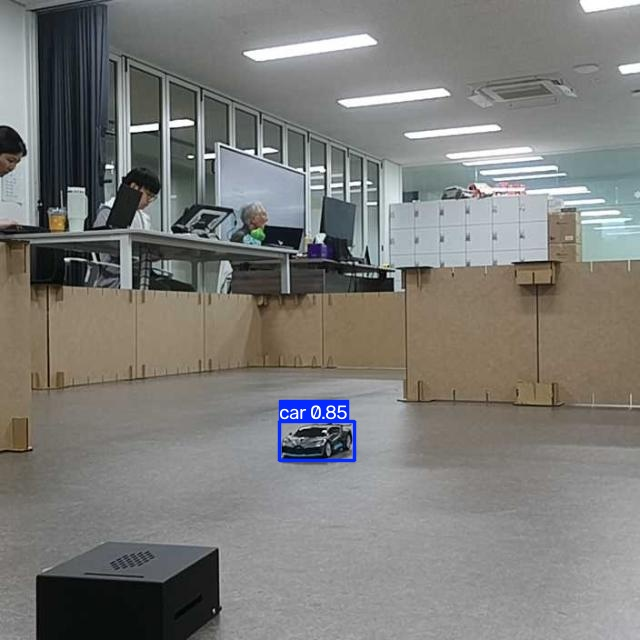

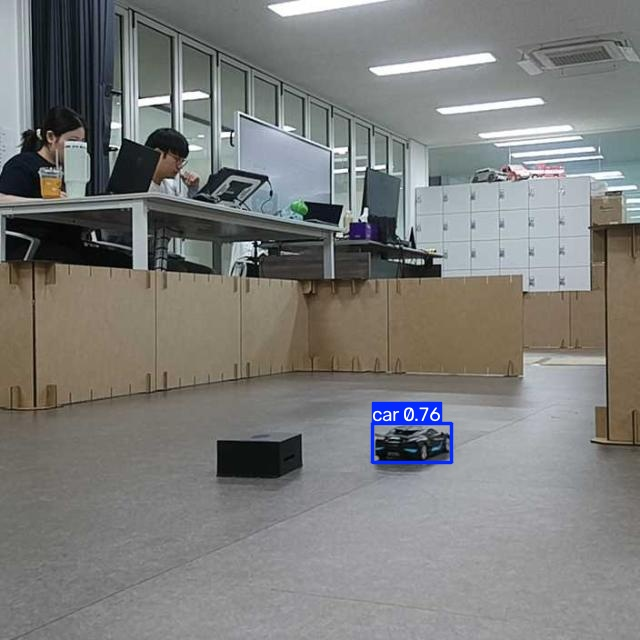

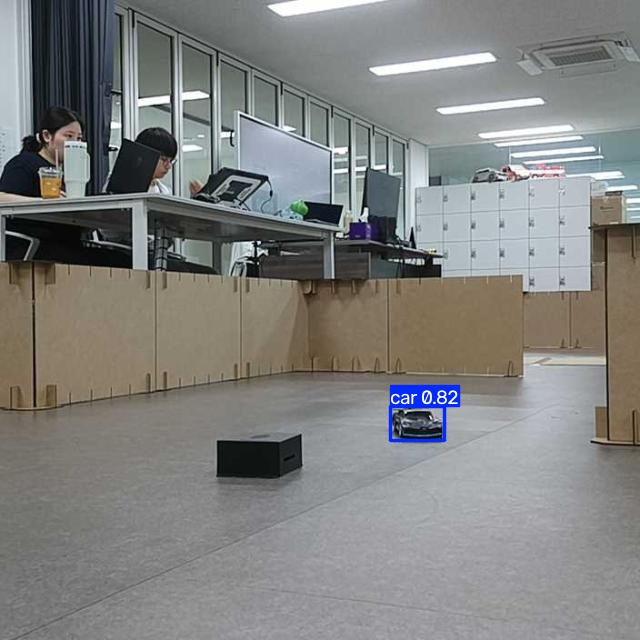

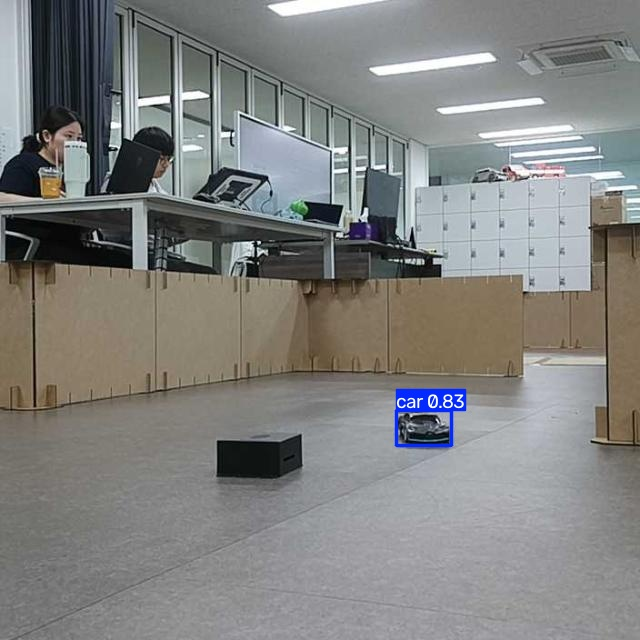

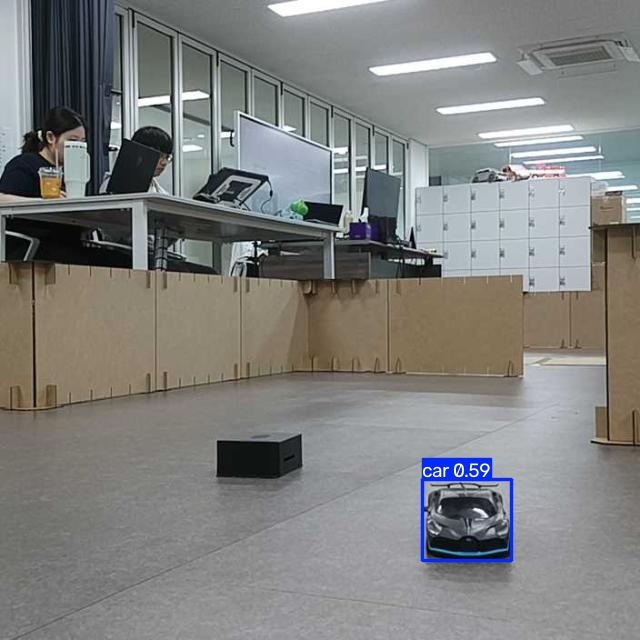

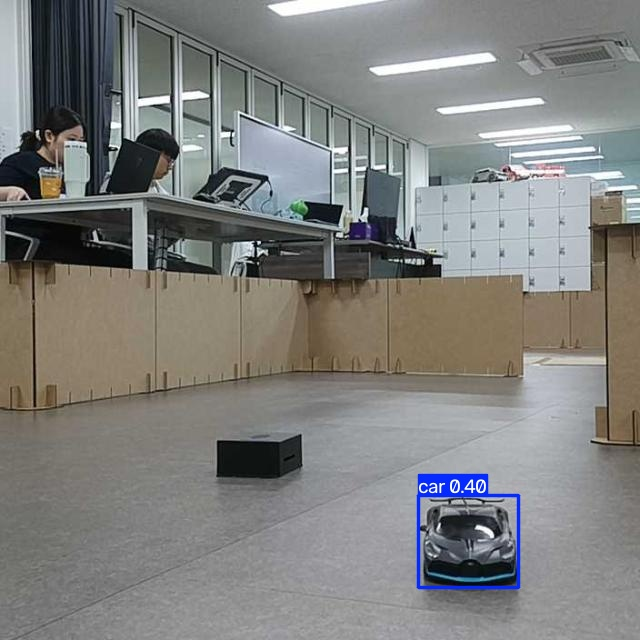

In [11]:
pred = best_model.predict(source=str(DATASET_DIR / 'test' / 'images'), conf=0.25, save=True,
                          device=DEVICE, project=str(RUNS_DIR), name=RUN_NAME + '_predict', exist_ok=True)
PRED_DIR = Path(pred[0].save_dir)
print('예측 결과 폴더:', PRED_DIR)

for p in sorted(PRED_DIR.glob('*.jpg'))[:6]:
    display(Image(filename=str(p), width=600))

## 8. 트래킹 (객체 추적)
학습한 탐지 모델에 `model.track()`을 쓰면 프레임 간 같은 객체에 **ID**가 붙습니다.

- `tracker='bytetrack.yaml'` (빠름) 또는 `'botsort.yaml'` (기본값, 조금 더 정확)
- `persist=True` : 프레임을 하나씩 넣을 때 이전 프레임의 트랙 정보를 유지

### 8-1. 테스트용 영상 만들기
별도 영상이 없으면 데이터셋 이미지(`frame_xxxxx`)를 프레임 순서대로 이어 붙여 영상을 만듭니다. 직접 찍은 영상이 있으면 `VIDEO_PATH`만 바꾸세요.

In [12]:
import re

def frame_key(p):
    m = re.search(r'frame_(\d+)', p.name)
    return int(m.group(1)) if m else p.name

frames = sorted([p for s in ['train', 'valid', 'test'] for p in (DATASET_DIR / s / 'images').glob('*')
                 if p.suffix.lower() in IMG_EXT], key=frame_key)

VIDEO_PATH = WORK_DIR / 'track_test.mp4'
first = cv2.imread(str(frames[0]))
H, W = first.shape[:2]
writer = cv2.VideoWriter(str(VIDEO_PATH), cv2.VideoWriter_fourcc(*'mp4v'), 5, (W, H))
for p in frames:
    f = cv2.imread(str(p))
    writer.write(cv2.resize(f, (W, H)))
writer.release()
print(f'{len(frames)} 프레임 → {VIDEO_PATH}')

124 프레임 → /home/hv-06/rokey_ws/track_test.mp4


### 8-2. 영상 파일 트래킹 (결과 영상 저장)

In [13]:
track_results = best_model.track(
    source=str(VIDEO_PATH),
    tracker='bytetrack.yaml',
    conf=0.3,
    persist=True,
    save=True,
    device=DEVICE,
    project=str(RUNS_DIR), name=RUN_NAME + '_track', exist_ok=True,
    stream=True,          # 긴 영상에서도 메모리 폭주 방지
)

track_ids = set()
for r in track_results:
    if r.boxes.id is not None:
        track_ids.update(r.boxes.id.int().tolist())
    save_dir = r.save_dir

print('결과 폴더:', save_dir)
print('발견된 트랙 ID:', sorted(track_ids))


video 1/1 (frame 1/124) /home/hv-06/rokey_ws/track_test.mp4: 640x640 1 car, 6.3ms
video 1/1 (frame 2/124) /home/hv-06/rokey_ws/track_test.mp4: 640x640 1 car, 6.3ms
video 1/1 (frame 3/124) /home/hv-06/rokey_ws/track_test.mp4: 640x640 1 car, 6.0ms
video 1/1 (frame 4/124) /home/hv-06/rokey_ws/track_test.mp4: 640x640 1 car, 6.5ms
video 1/1 (frame 5/124) /home/hv-06/rokey_ws/track_test.mp4: 640x640 1 car, 6.1ms
video 1/1 (frame 6/124) /home/hv-06/rokey_ws/track_test.mp4: 640x640 1 car, 6.3ms
video 1/1 (frame 7/124) /home/hv-06/rokey_ws/track_test.mp4: 640x640 1 car, 6.3ms
video 1/1 (frame 8/124) /home/hv-06/rokey_ws/track_test.mp4: 640x640 1 car, 6.1ms
video 1/1 (frame 9/124) /home/hv-06/rokey_ws/track_test.mp4: 640x640 1 car, 6.4ms
video 1/1 (frame 10/124) /home/hv-06/rokey_ws/track_test.mp4: 640x640 1 car, 6.3ms
video 1/1 (frame 11/124) /home/hv-06/rokey_ws/track_test.mp4: 640x640 1 car, 6.3ms
video 1/1 (frame 12/124) /home/hv-06/rokey_ws/track_test.mp4: 640x640 1 car, 6.2ms
video 1/1 (f

### 8-3. 프레임 단위 트래킹 (ID별 정보 직접 사용하기)
로봇 제어 등에 쓰려면 이렇게 프레임마다 `id, class, 좌표`를 꺼내서 쓰면 됩니다.

ID 51: 12 프레임 동안 추적
ID 53: 3 프레임 동안 추적
ID 54: 25 프레임 동안 추적
ID 50: 5 프레임 동안 추적
ID 59: 2 프레임 동안 추적
ID 60: 1 프레임 동안 추적
ID 61: 1 프레임 동안 추적
ID 68: 1 프레임 동안 추적
ID 70: 2 프레임 동안 추적
ID 72: 3 프레임 동안 추적
ID 79: 5 프레임 동안 추적
ID 91: 9 프레임 동안 추적
ID 92: 1 프레임 동안 추적
ID 98: 1 프레임 동안 추적


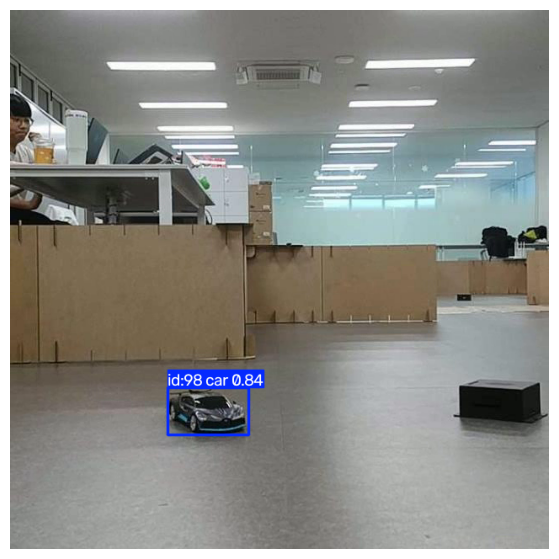

In [14]:
import numpy as np
from collections import defaultdict

track_history = defaultdict(list)   # id -> 중심점 이동 경로
cap = cv2.VideoCapture(str(VIDEO_PATH))
last_frame = None

while cap.isOpened():
    ok, frame = cap.read()
    if not ok:
        break
    r = best_model.track(frame, persist=True, tracker='bytetrack.yaml', conf=0.3, device=DEVICE, verbose=False)[0]
    annotated = r.plot()
    if r.boxes.id is not None:
        for (x, y, w, h), tid, cls in zip(r.boxes.xywh.cpu().numpy(), r.boxes.id.int().tolist(), r.boxes.cls.int().tolist()):
            track_history[tid].append((float(x), float(y)))
            pts = np.array(track_history[tid][-30:], dtype=np.int32).reshape(-1, 1, 2)
            cv2.polylines(annotated, [pts], False, (0, 255, 255), 2)
    last_frame = annotated
cap.release()

for tid, pts in track_history.items():
    print(f'ID {tid}: {len(pts)} 프레임 동안 추적')

if last_frame is not None:
    plt.figure(figsize=(10, 7)); plt.imshow(cv2.cvtColor(last_frame, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.show()

### 8-4. 웹캠 실시간 트래킹 (선택)
별도 창이 뜹니다. `q`를 누르면 종료. 웹캠 번호가 다르면 `CAM_ID`를 바꾸세요.

In [15]:
RUN_WEBCAM = False   # 실행하려면 True
CAM_ID = 0

if RUN_WEBCAM:
    cap = cv2.VideoCapture(CAM_ID)
    try:
        while cap.isOpened():
            ok, frame = cap.read()
            if not ok:
                break
            r = best_model.track(frame, persist=True, tracker='bytetrack.yaml', conf=0.3, device=DEVICE, verbose=False)[0]
            cv2.imshow(f'YOLO{MODEL_TAG} Tracking', r.plot())
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
    finally:
        cap.release()
        cv2.destroyAllWindows()

## 9. 학습된 모델 저장
`best.pt`를 알아보기 쉬운 이름으로 복사합니다.

In [16]:
import shutil

OUT_PT = WORK_DIR / f'my_best{MODEL_TAG}.pt'   # my_best26n.pt ...
shutil.copy(BEST_PT, OUT_PT)
print('저장 완료:', OUT_PT)

저장 완료: /home/hv-06/rokey_ws/my_bestv8s.pt


## 10. 학습 통계 리포트
`yolo_stats.py`로 이번 학습 결과(`TRAIN_DIR`)의 그래프/통계표를 만듭니다. 결과는 `TRAIN_DIR/stats/`에 저장됩니다.

분석 대상: /home/hv-06/rokey_ws/runs/car_dummy_v8s  (model=yolov8s.pt, data=/home/hv-06/rokey_ws/custom_data.yaml)


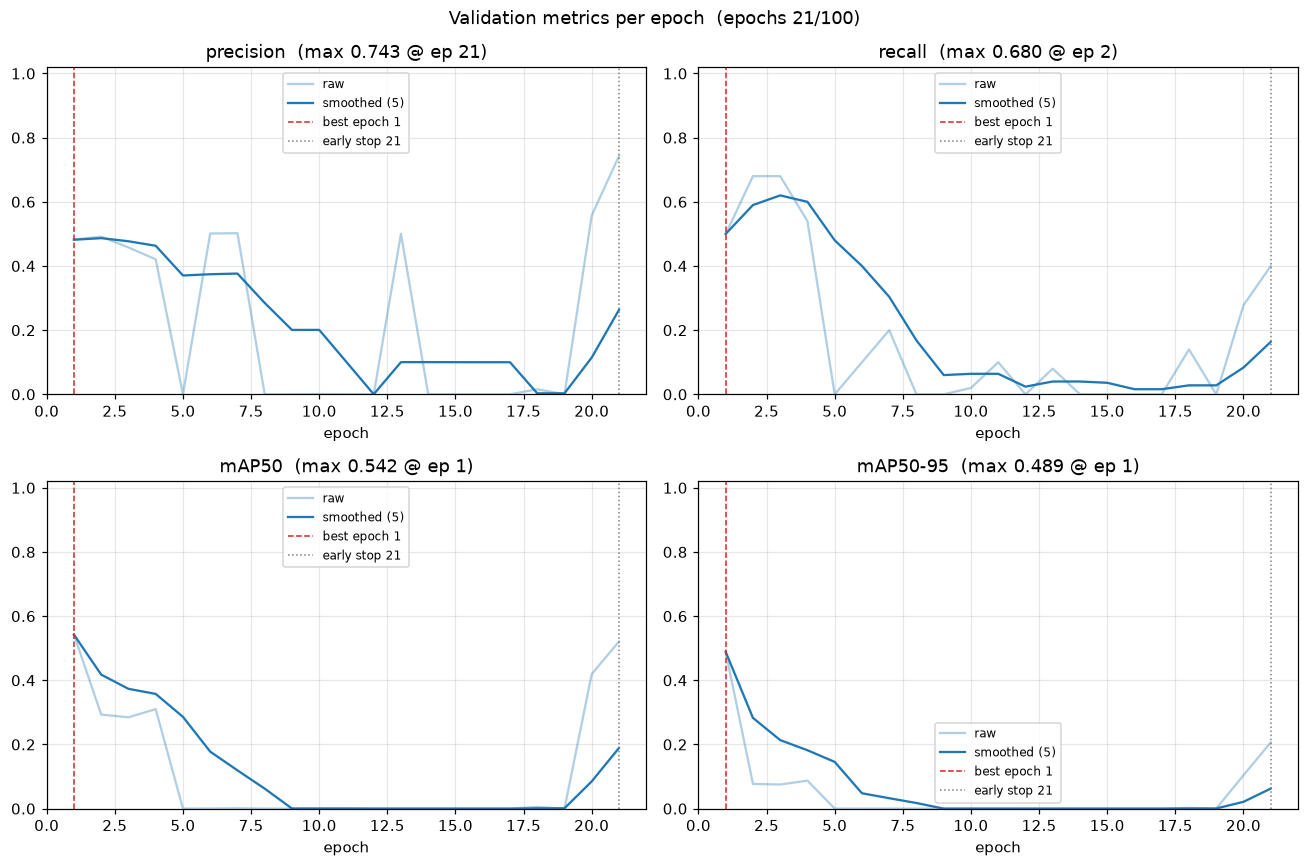

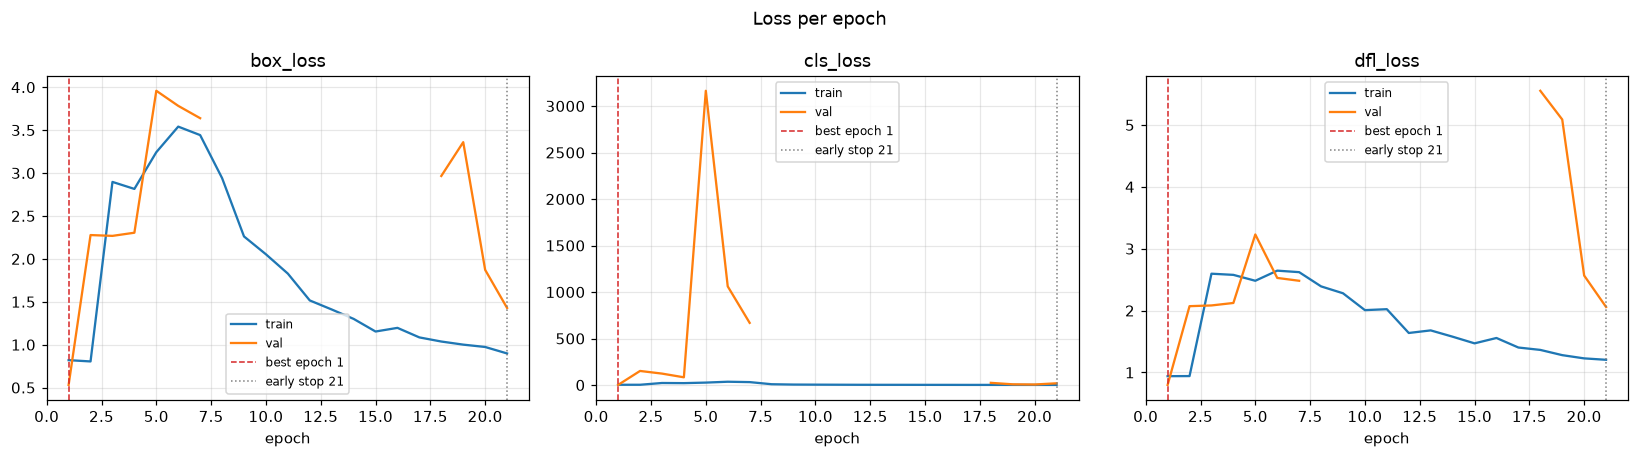

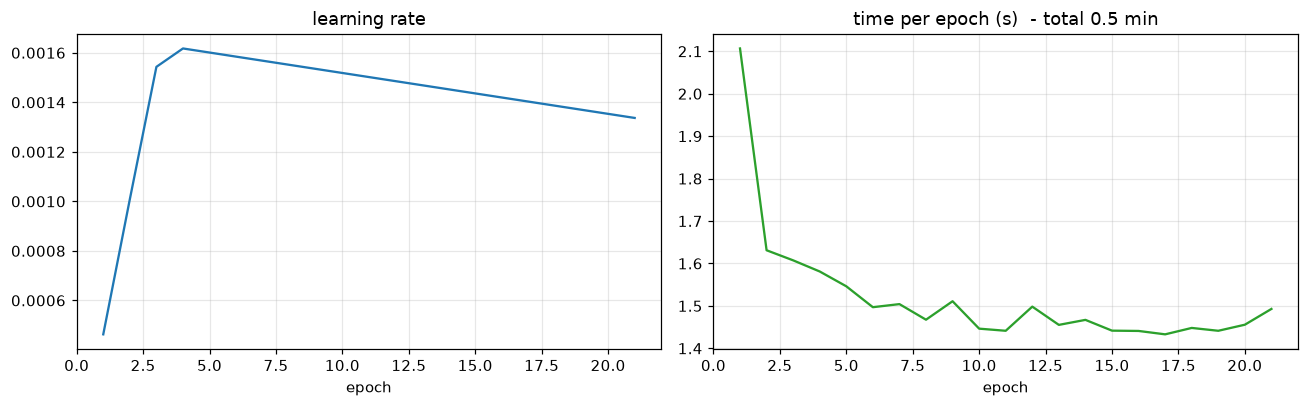

Ultralytics 8.4.170 🚀 Python-3.12.3 torch-2.14.1+cu130 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 5804MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4167.3±934.0 MB/s, size: 46.7 KB)
val: Scanning /home/hv-06/Downloads/yolo88/valid/labels.cache... 25 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 25/25 17.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 4.2it/s 0.5s1.1s
                   all         25         50      0.482        0.5      0.542      0.487
Speed: 0.4ms preprocess, 9.1ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /home/hv-06/rokey_ws/runs/car_dummy_v8s/stats/_val_val
Ultralytics 8.4.170 🚀 Python-3.12.3 torch-2.14.1+cu130 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 5804MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access 

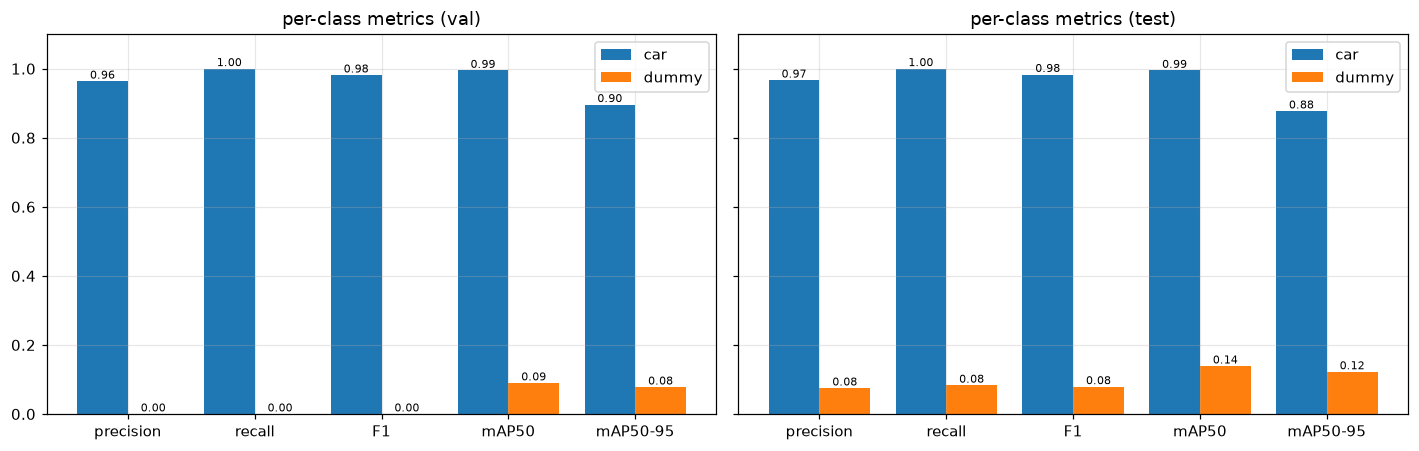

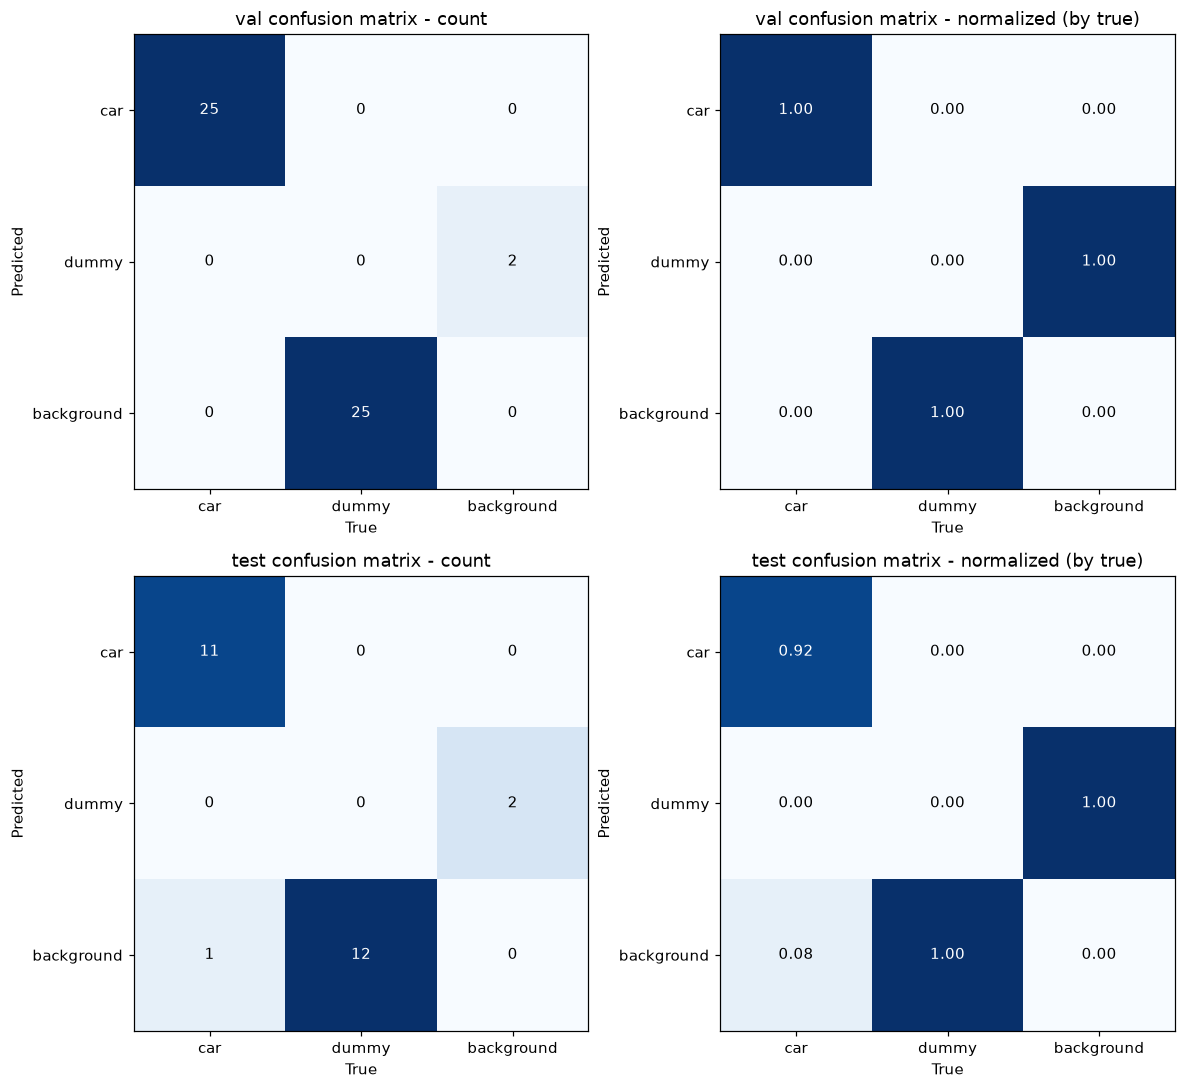

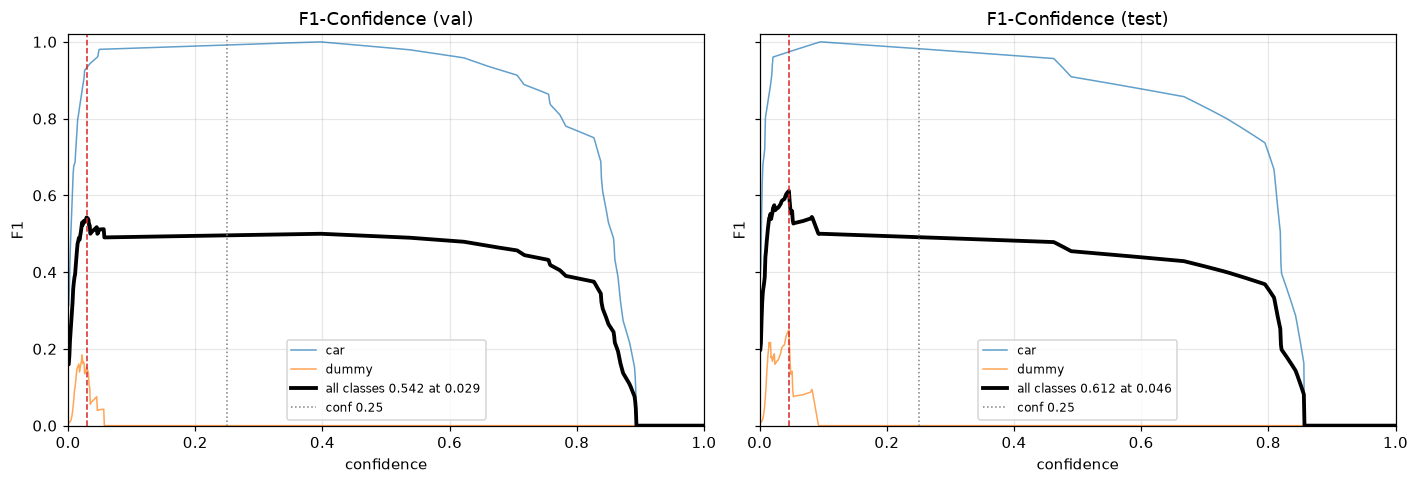

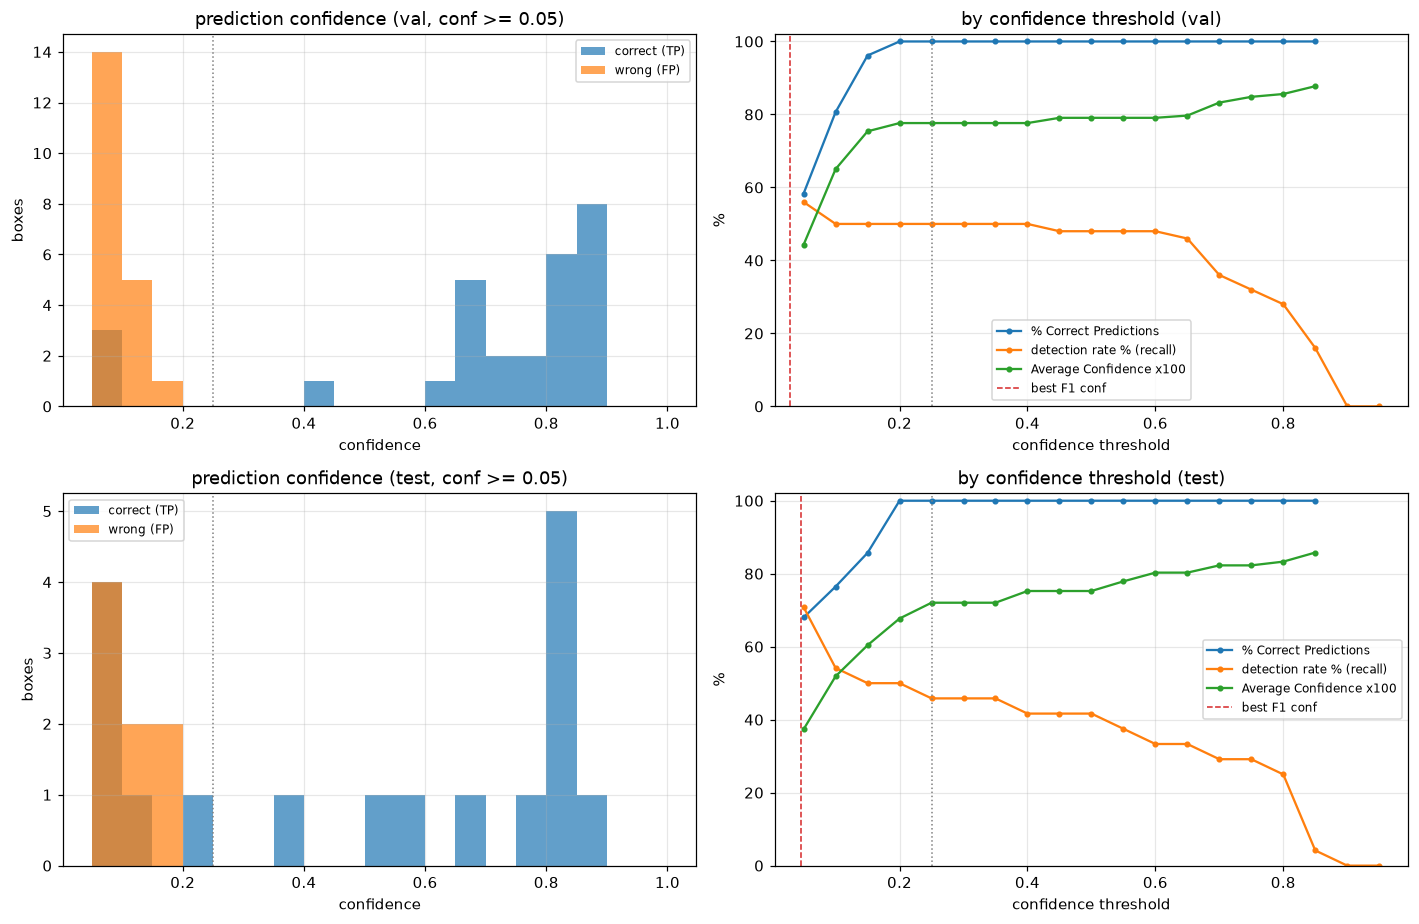

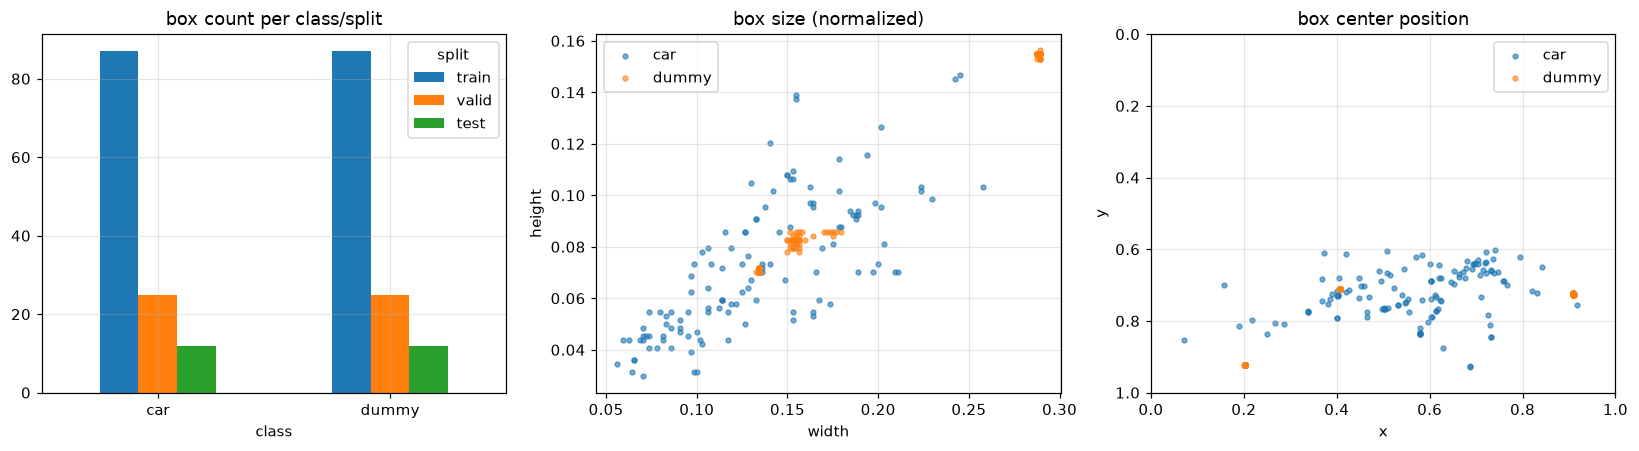

# YOLO 학습 통계 (car_dummy_v8s, model=yolov8s.pt)

## 학습 정보
- 모델: yolov8s.pt
- Epochs: 설정 100 / 실제 21 / best 1 (patience 20)
- 종료 상태: 조기 종료 (epoch 21에서 종료, 20 epoch 동안 개선 없음)
- Total Training Time: 0분 32초 (results.csv 기준)
- 실제 소요 시간(준비·최종 검증 포함): 0분 37초
- Training Hyper Parameters (학습 노트북 TRAIN_ARGS (train_info.yaml)):
    epochs: 100
    patience: 20
    imgsz: 640
    batch: 16
    workers: 2

## 핵심 지표 (test, best.pt)
- mAP50 / mAP50-95: 0.5669 / 0.4998
- F1-Confidence: 최고 F1 0.6116 (confidence 0.046)
- % Correct Predictions @conf 0.25: 100.00% (예측 박스 중 IoU>=0.5로 맞은 비율)
- Average Confidence @conf 0.25: 0.7205
- Inference Speed (batch=1, 10장 평균): preprocess 0.49 + inference 6.40 + postprocess 0.37 = 7.26 ms/img (137.8 FPS)

## 전체 성능 (best.pt)
split  precision  recall     F1  mAP50  mAP75  mAP50-95  best F1 (F1-Confidence)  best F1 conf  % Correct @0.25  Avg Conf @0.25
  val     0.4819  0.5000 0.4908 0.5425 0.5425    0.4869                   0.5423        0.0290         100.0000          

In [17]:
%run yolo_stats.py {TRAIN_DIR}

## 11. 모델 비교 (선택)
여러 모델을 학습한 뒤 `runs/` 아래 결과를 모두 같은 조건으로 비교합니다. 결과는 `runs/compare/`에 저장됩니다. 실행하려면 `RUN_COMPARE = True`로 바꾸세요.

In [19]:
RUN_COMPARE = False   # 실행하려면 True (runs/ 아래 학습 결과 전부 비교)

if RUN_COMPARE:
    %run yolo_compare.py